In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from itertools import product
from wrf_io import postproc
from matplotlib.patches import Patch

In [3]:
fontsize = 24
plt.rcParams['xtick.labelsize'] = 20 
plt.rcParams['ytick.labelsize'] = 20 

plt.rcParams.update({
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

In [6]:
veer  = np.array([-80,-70,-60,-50,-40,-30,-20,-10,0,10,20,30,40,50,60,70,80])
shear = np.array([-6,-4,-2,0,2,4,6])

training = [pair for pair in product(shear, veer)]

# allowed_values = [-80, -40, -20, -10, 0, 10, 20, 40, 80]
allowed_values = [0]
subset_indices = [i for i, (s, v) in enumerate(training) if (v in allowed_values and abs(s) == 0)]

subset_indices

[59]

In [7]:
casenames = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/sweep_names.npy')
U_loc   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy')
dir_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy')
Uhub    = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/Uhub.npy')
wrf_rel = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_rel.npy')
wrf_phi = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_phi.npy')
wrf_vax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vax.npy')
wrf_vtn = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_vtn.npy')
wrf_cax = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cax.npy')
wrf_cot = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_cot.npy')
wrf_ind = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_ind.npy')
wrf_thr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_thr.npy')
wrf_pow = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_pow.npy')
shapiro = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/shapiro.npy')
wrf_tsr = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_tsr.npy')
wrf_omg = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_omg.npy')
Nelm    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nelm']
Nsct    = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['Nsct']
rOverR  = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['rOverR']
R       = np.load("/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/rotor_dims_10MW.npz")['R']
wrf_L   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_L.npy')
wrf_D   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_D.npy')
wrf_CL   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_CL.npy')
wrf_CD   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_CD.npy')
wrf_W   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_W.npy')

In [8]:
arr = wrf_thr
for i in range(0, len(arr), 5):
    line = ", ".join(f"{x:10.1f}" for x in arr[i:i+5])
    print(line)

  686505.9,   690425.7,   694939.4,   700013.9,   705539.1
  711019.1,   715769.1,   719310.0,   721872.8,   723605.8
  724103.6,   722806.6,   720495.4,   718381.8,   716648.8
  715395.2,   714653.9,   685672.3,   689539.9,   693888.8
  698563.6,   703401.9,   708046.0,   712135.0,   715486.0
  718030.6,   719646.1,   720288.7,   719906.9,   718632.2
  716919.9,   715218.2,   713751.2,   712770.1,   685237.6
  688915.2,   693013.8,   697391.8,   701832.7,   706080.2
  709925.8,   713181.2,   715675.6,   717238.9,   717874.9
  717674.4,   716806.4,   715514.7,   714112.3,   712879.7
  712006.8,   685026.3,   688639.4,   692655.9,   696923.9
  701244.6,   705382.4,   709146.6,   712368.0,   714829.8
  716384.2,   717014.8,   716880.6,   716125.0,   714960.8
  713673.0,   712522.4,   711706.8,   685091.4,   688744.9
  692822.9,   697171.9,   701575.1,   705777.7,   709606.4
  712867.7,   715357.2,   716925.2,   717579.6,   717447.3
  716672.2,   715440.4,   714083.2,   712886.8,   712051

In [9]:
replacements = {
    'sn030151': 'sn06',
    'sn020101': 'sn04',
    'sn010050': 'sn02',
    's000000' : 's00',
    's010050' : 's02',
    's020101' : 's04',
    's030151' : 's06',
    'vn402010' : 'vn80',
    'vn351759' : 'vn70',
    'vn301508' : 'vn60',
    'vn251256' : 'vn50',
    'vn201005' : 'vn40',
    'vn150754' : 'vn30',
    'vn100503' : 'vn20',
    'vn050251' : 'vn10',
    'v000000'  : 'v00',
    'v050251'  : 'v10',
    'v100503'  : 'v20',
    'v150754'  : 'v30',
    'v201005'  : 'v40',
    'v251256'  : 'v50',
    'v301508'  : 'v60',
    'v351759'  : 'v70',
    'v402010'  : 'v80'
}

sub_cases = [np.array(casenames)[subset_indices]]

formatted_cases = []
for name in sub_cases[0]:
    for old, new in replacements.items():
        if old in name:
            name = name.replace(old, new)
    formatted_cases.append(name)

# Result
new_names = np.array(formatted_cases)

In [47]:
from MITRotor import BEM, BEMGeometry, IEA10MW, NoTipLoss, KraghAerodynamics, NoTangentialInduction, ConstantInduction

In [48]:
U_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/U_loc.npy')

dir_loc = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/dir_loc.npy')

## Total error

In [49]:
rotor = IEA10MW()

mit_cot = np.zeros_like(subset_indices, dtype='float')
mit_cop = np.zeros_like(subset_indices, dtype='float')
iters   = np.zeros_like(subset_indices, dtype='float')

T_total = np.zeros_like(subset_indices, dtype='float')
P_total = np.zeros_like(subset_indices, dtype='float')

wrf_T_total = np.zeros_like(subset_indices, dtype='float')
wrf_P_total = np.zeros_like(subset_indices, dtype='float')

mit_CL = np.zeros_like(wrf_CL[:,:,subset_indices], dtype='float')
mit_CD = np.zeros_like(wrf_CD[:,:,subset_indices], dtype='float')

mit_L = np.zeros_like(wrf_CL[:,:,subset_indices], dtype='float')
mit_D = np.zeros_like(wrf_CD[:,:,subset_indices], dtype='float')

mit_FN = np.zeros_like(wrf_CL[:,:,subset_indices], dtype='float')
mit_FT = np.zeros_like(wrf_CD[:,:,subset_indices], dtype='float')

mit_W = np.zeros_like(wrf_W[:,:,subset_indices], dtype='float')
mit_Vrel = np.zeros_like(wrf_W[:,:,subset_indices], dtype='float')
mit_Vax = np.zeros_like(wrf_vax[:,:,subset_indices], dtype='float')
mit_Vtn = np.zeros_like(wrf_vtn[:,:,subset_indices], dtype='float')
mit_phi = np.zeros_like(wrf_phi[:,:,subset_indices], dtype='float')
mit_U = np.zeros_like(wrf_phi[:,:,subset_indices], dtype='float')

Nr = 26
NSct = 158

for count in range(len(subset_indices)):

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nr,Ntheta=Nsct), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0.0), tangential_induction_model=NoTangentialInduction(),index = subset_indices[count])

    tsr = wrf_tsr[subset_indices[count]]

    sol = bem(0, tsr, 0, U = U_loc[:,:,subset_indices[count]], wdir=dir_loc[:,:,subset_indices[count]], index = subset_indices[count])

    rho = 1.225

    r = rOverR * R

    dr = (R - rotor.hub_radius)/Nelm

    dtheta = 2 * np.pi / Nsct

    chord = np.array([4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734])
    rho = 1.225

    Vrel = np.sqrt((sol.Vax('sector'))**2 + sol.Vtan('sector')**2) * Uhub[subset_indices[count]]

    # L = 1/2 * rho * chord * (sol.Cl('sector') * Vrel**2).T
    # D = 1/2 * rho * chord * (sol.Cd('sector') * Vrel**2).T
    L = 1/2 * rho * chord * (sol.Cl('sector') * (sol.W('sector') * Uhub[subset_indices[count]])**2).T
    D = 1/2 * rho * chord * (sol.Cd('sector') * (sol.W('sector') * Uhub[subset_indices[count]])**2).T

    phi = sol.phi('sector')

    FT = L.T * np.sin(phi) - D.T * np.cos(phi)
    FN = L.T * np.cos(phi) + D.T * np.sin(phi)

    sigma = 3/Nsct

    T = FN * dr * sigma

    # P = FT.T * r * dr * sigma * wrf_omg[subset_indices[count]] * 2 * np.pi / 60
    P = FT.T * r * dr * sigma * tsr * Uhub[subset_indices[count]] / R

    T_total[count] = np.sum(T)/1e3
    P_total[count] = np.sum(P)/1e6


    L = 1/2 * rho * chord * (wrf_CL[:,:,subset_indices[count]] * (wrf_W[:,:,subset_indices[count]] * Uhub[subset_indices[count]])**2).T
    D = 1/2 * rho * chord * (wrf_CD[:,:,subset_indices[count]] * (wrf_W[:,:,subset_indices[count]] * Uhub[subset_indices[count]])**2).T

    FT = L.T * np.sin(wrf_phi[:,:,subset_indices[count]]) - D.T * np.cos(wrf_phi[:,:,subset_indices[count]])
    FN = L.T * np.cos(wrf_phi[:,:,subset_indices[count]]) + D.T * np.sin(wrf_phi[:,:,subset_indices[count]])

    T = FN * dr * sigma
    P = FT.T * r * dr * sigma * tsr * Uhub[subset_indices[count]] / R

    wrf_T_total[count] = np.sum(T)/1e3

    mit_cot[count] = sol.Ct()
    mit_cop[count] = sol.Cp()

    mit_CL[:,:,count] = sol.Cl('sector')
    mit_CD[:,:,count] = sol.Cd('sector')

    mit_L[:,:,count] = L.T
    mit_D[:,:,count] = D.T

    mit_FN[:,:,count] = FN
    mit_FT[:,:,count] = FT

    mit_W[:,:,count] = sol.W('sector')
    mit_Vrel[:,:,count] = Vrel
    mit_Vax[:,:,count] = sol.Vax('sector')
    mit_Vtn[:,:,count] = sol.Vtan('sector')
    mit_phi[:,:,count] = sol.phi('sector')
    mit_U[:,:,count] = sol.U('sector')

    iters[count] = sol.niter

iters

59
59
59


array([1.])

In [45]:
rotor.solidity(rOverR)[:,0]

array([0.5201772 , 0.28906983, 0.21223192, 0.17429244, 0.14746034,
       0.12412067, 0.10403464, 0.0874549 , 0.07374013, 0.06231282,
       0.05276398, 0.04476808, 0.03804555, 0.03237927, 0.02760791,
       0.02358984, 0.02020329, 0.01734945, 0.01494123, 0.01291867,
       0.01121999, 0.00976516, 0.00843443, 0.0069307 , 0.00404511,
       0.00280417])

In [57]:
wrf_FT = wrf_L[:,:,:] * np.sin(wrf_phi[:,:,:]) - wrf_D[:,:,:] * np.cos(wrf_phi[:,:,:])
wrf_FN = wrf_L[:,:,:] * np.cos(wrf_phi[:,:,:]) + wrf_D[:,:,:] * np.sin(wrf_phi[:,:,:])

In [ ]:
sol.Cl('sector')

mit_CL   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_CL.npy')
mit_CD   = np.load('/scratch/09909/smata/induction_modeling/madsen_modeling/rotorAvg_10MW/processedData/wrf_CD.npy')

array([[0.01079754, 0.01100953, 0.01097749, ..., 0.01085207, 0.01083508,
        0.01081676],
       [0.20404014, 0.20605854, 0.20551012, ..., 0.20502053, 0.20469884,
        0.20437093],
       [0.62535758, 0.62471596, 0.62508555, ..., 0.62448572, 0.62480347,
        0.62509134],
       ...,
       [1.34146479, 1.34118132, 1.32899664, ..., 1.33317766, 1.33112221,
        1.3422375 ],
       [1.21596643, 1.21636991, 1.21818903, ..., 1.22377651, 1.22037285,
        1.21746413],
       [1.18472944, 1.18401021, 1.18300653, ..., 1.18516563, 1.18526142,
        1.18514863]], shape=(26, 158))

In [58]:
wrf_FT[:,:,subset_indices] - mit_FT

array([[[-1.00432318e+01, -9.83468426e+00, -9.63081241e+00, ...,
         -8.70579251e+00, -8.05862799e+00, -6.82448119e+00],
        [-9.53141967e+00, -9.27229024e+00, -9.04376957e+00, ...,
         -8.07751371e+00, -7.41936883e+00, -6.17052259e+00],
        [-9.40638959e+00, -9.14595144e+00, -8.91816007e+00, ...,
         -7.96200085e+00, -7.31331353e+00, -6.08410303e+00],
        ...,
        [-9.69694305e+00, -9.49604286e+00, -9.30060581e+00, ...,
         -8.41378511e+00, -7.79441738e+00, -6.62029253e+00],
        [-9.91344258e+00, -9.71074233e+00, -9.51174819e+00, ...,
         -8.60460485e+00, -7.96921033e+00, -6.76056219e+00],
        [-1.00094102e+01, -9.80372552e+00, -9.60189160e+00, ...,
         -8.68315301e+00, -8.03966512e+00, -6.81355063e+00]],

       [[ 6.70326885e+00,  8.15904571e+00,  8.72116471e+00, ...,
          8.41095847e+00,  7.26846723e+00,  4.00902796e+00],
        [ 6.97691028e+00,  8.51837648e+00,  9.12373353e+00, ...,
          8.87036389e+00,  7.72680916e

In [53]:
wrf_FN[:,:,subset_indices] - mit_FN

array([[[-7.15153354e-05, -6.90129599e-04, -2.01914220e-03, ...,
         -7.58239886e-03, -1.15254645e-02, -2.12606153e-02],
        [ 4.01459790e-02,  4.12696423e-02,  4.10882324e-02, ...,
          3.80567465e-02,  3.49021619e-02,  2.73361386e-02],
        [ 8.22069766e-02,  8.79853878e-02,  9.07116613e-02, ...,
          9.47766438e-02,  9.47143992e-02,  9.46325826e-02],
        ...,
        [-1.08201921e-01, -1.24443670e-01, -1.35339015e-01, ...,
         -1.63745155e-01, -1.77211700e-01, -2.09175342e-01],
        [-7.40181454e-02, -8.49818418e-02, -9.26902869e-02, ...,
         -1.13488664e-01, -1.23808912e-01, -1.48537442e-01],
        [-3.78914294e-02, -4.34472005e-02, -4.78060180e-02, ...,
         -6.06913330e-02, -6.76658442e-02, -8.47342729e-02]],

       [[-1.48706372e-02,  4.45574515e-05,  9.23411094e-04, ...,
         -1.59138802e-02, -3.30246747e-02, -8.04677309e-02],
        [ 1.44340155e-01,  1.65381255e-01,  1.68978405e-01, ...,
          1.55090853e-01,  1.36381069e

In [42]:
wrf_W[:,:,subset_indices] - mit_W

array([[[-5.27450393e-06, -5.22506460e-05, -1.51827218e-04, ...,
         -5.51088036e-04, -8.12874663e-04, -1.42882266e-03],
        [-4.31554332e-05, -2.76904928e-04, -4.84052353e-04, ...,
         -1.13512097e-03, -1.51873508e-03, -2.37882355e-03],
        [-2.70794271e-05, -2.34069315e-04, -4.26732521e-04, ...,
         -1.04707073e-03, -1.41704688e-03, -2.24958754e-03],
        ...,
        [-9.54576256e-08, -9.47518105e-05, -2.16141842e-04, ...,
         -6.56029195e-04, -9.32245020e-04, -1.57138032e-03],
        [-2.93906328e-07, -7.91404054e-05, -1.94055090e-04, ...,
         -6.21912697e-04, -8.94270897e-04, -1.52799011e-03],
        [-1.87731581e-06, -6.51031304e-05, -1.72709197e-04, ...,
         -5.86985485e-04, -8.54107602e-04, -1.48056548e-03]],

       [[-3.21094062e-04,  1.02105100e-06,  2.00028239e-05, ...,
         -3.28185838e-04, -6.69274526e-04, -1.57249810e-03],
        [-6.04866893e-05,  7.51929441e-05, -3.56161994e-05, ...,
         -7.26807226e-04, -1.26269301e

In [20]:
wrf_L[:,:,subset_indices] - mit_L

array([[[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        ...,
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00]],

       [[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e+00,  0.00000000e+00],
        [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00, ...,
          0.00000000e+00,  0.00000000e

In [157]:
FT

array([[[-34.36468637, -34.47491128, -34.6100082 , ..., -34.57425181,
         -34.49432335, -34.43975888],
        [-34.64893019, -34.75883653, -34.89688743, ..., -35.07681597,
         -35.01139231, -34.97121076],
        [-34.55172817, -34.66020366, -34.79666278, ..., -35.14847591,
         -35.08569761, -35.04823276],
        ...,
        [-34.60725871, -34.71976851, -34.8566722 , ..., -34.28786284,
         -34.19629907, -34.12990778],
        [-34.52513658, -34.63709393, -34.77362927, ..., -34.38515041,
         -34.29769547, -34.23547709],
        [-34.4442241 , -34.55541748, -34.69134271, ..., -34.48069033,
         -34.39711944, -34.33885499]],

       [[-73.90093521, -74.64132518, -75.35904307, ..., -79.25022937,
         -79.63111668, -80.14174248],
        [-74.62976972, -75.38727335, -76.13494882, ..., -80.63338136,
         -81.07679828, -81.6489664 ],
        [-74.288386  , -75.03891218, -75.78084856, ..., -80.826934  ,
         -81.2781967 , -81.85726419],
        ...,


In [159]:
dr = wrf_thr[0] / (np.sum(FN[:,:,0]) * sigma)
dr

np.float64(3.7401470705043574)

In [49]:
dr

np.float64(3.7346153846153842)

In [199]:
(R - rotor.hub_radius)/Nelm

np.float64(3.7346153846153842)

In [187]:
rOverR * R

array([ 4.26730769,  8.00192308, 11.73653846, 15.47115385, 19.20576923,
       22.94038462, 26.675     , 30.40961538, 34.14423077, 37.87884615,
       41.61346154, 45.34807692, 49.08269231, 52.81730769, 56.55192308,
       60.28653846, 64.02115385, 67.75576923, 71.49038462, 75.225     ,
       78.95961538, 82.69423077, 86.42884615, 90.16346154, 93.89807692,
       97.63269231])

In [179]:
C = dr * sigma * wrf_tsr * Uhub / R     # shape (119,)
S = np.sum(FT, axis=1)              # shape (26,119)
S.shape

(26, 119)

In [196]:
base_r = np.linspace(rOverR[0]*R, rOverR[-1]*R, 26)  # avoid 0 at the root
r = np.zeros_like(S)

for i in range(wrf_pow.shape[0]):
    denom = np.sum(S[:, i] * base_r)
    x = wrf_pow[i] / (C[i] * denom)
    r[:, i] = base_r * x

r[:,0]

array([ 3.95838307,  7.42263721, 10.88689134, 14.35114548, 17.81539961,
       21.27965375, 24.74390788, 28.20816202, 31.67241615, 35.13667029,
       38.60092442, 42.06517856, 45.52943269, 48.99368683, 52.45794096,
       55.9221951 , 59.38644923, 62.85070337, 66.3149575 , 69.77921164,
       73.24346577, 76.70771991, 80.17197404, 83.63622818, 87.10048231,
       90.56473644])

In [175]:
A = S[:, i][:, np.newaxis]
A.shape

(26, 1)

In [167]:
wrf_pow.shape[0]

119

In [6]:
rhub = 4.8/2
dist = 0.0
dr = (99.5 - 2.4) / 26
r = np.zeros((26))
for i in range(0,26):
    dist = dist + 0.5*dr
    r[i] = rhub + dist
    dist = dist + 0.5*dr

dr

3.7346153846153842

In [7]:
r

array([ 4.26730769,  8.00192308, 11.73653846, 15.47115385, 19.20576923,
       22.94038462, 26.675     , 30.40961538, 34.14423077, 37.87884615,
       41.61346154, 45.34807692, 49.08269231, 52.81730769, 56.55192308,
       60.28653846, 64.02115385, 67.75576923, 71.49038462, 75.225     ,
       78.95961538, 82.69423077, 86.42884615, 90.16346154, 93.89807692,
       97.63269231])

In [149]:
np.array([0.04288751, 0.08042134, 0.11795516, 0.15548898, 0.19302281,0.23055663, 0.26809045, 0.30562428, 0.3431581 , 0.38069192,0.41822574, 0.45575957, 0.49329339, 0.53082721, 0.56836104,0.60589486, 0.64342868, 0.6809625 , 0.71849633, 0.75603015,0.79356397, 0.8310978 , 0.86863162, 0.90616544, 0.94369927,0.98123309]) * R

array([ 4.26730724,  8.00192333, 11.73653842, 15.47115351, 19.20576959,
       22.94038469, 26.67499977, 30.40961586, 34.14423095, 37.87884604,
       41.61346113, 45.34807722, 49.08269231, 52.8173074 , 56.55192348,
       60.28653857, 64.02115366, 67.75576875, 71.49038484, 75.22499992,
       78.95961501, 82.6942311 , 86.42884619, 90.16346128, 93.89807736,
       97.63269245])

In [86]:
r[1] - r[0]

np.float64(3.734615384615384)

In [87]:
rotor.hub_radius

2.4

In [26]:
mit_CL - wrf_CL[:,:,subset_indices]

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [27]:
mit_CD - wrf_CD[:,:,subset_indices]

array([[[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

In [65]:
mit_Vax - wrf_vax[:,:,subset_indices]

array([[[0.01926727, 0.01192117, 0.01030647, ..., 0.01995406,
         0.03142555, 0.05652076],
        [0.01899058, 0.01160888, 0.00997734, ..., 0.01960135,
         0.03106928, 0.05616059],
        [0.01872704, 0.01131062, 0.00966213, ..., 0.01926318,
         0.03072743, 0.05581358],
        ...,
        [0.02017143, 0.01293343, 0.01137102, ..., 0.02108873,
         0.03256897, 0.05767384],
        [0.0198586 , 0.01258422, 0.01100436, ..., 0.02069876,
         0.03217643, 0.05727871],
        [0.0195569 , 0.01224649, 0.01064932, ..., 0.02032015,
         0.03179469, 0.0568941 ]],

       [[0.02669516, 0.02028409, 0.0190832 , ..., 0.02937245,
         0.04107051, 0.06624271],
        [0.02669199, 0.0201704 , 0.01891311, ..., 0.02910489,
         0.04077085, 0.06587141],
        [0.02667461, 0.02004127, 0.01872714, ..., 0.02882045,
         0.04045376, 0.06548257],
        ...,
        [0.02665396, 0.02056116, 0.0195236 , ..., 0.03009337,
         0.041882  , 0.06726223],
        [0.0

In [66]:
mit_Vtn - wrf_vtn[:,:,subset_indices]

array([[[-6.62692303e-05,  1.26886735e-04,  1.87041359e-04, ...,
          6.93532063e-04,  1.33548856e-03,  3.23703289e-03],
        [ 1.84307641e-04,  2.84390154e-04,  3.22810164e-04, ...,
          9.76434468e-04,  1.80274987e-03,  4.14415012e-03],
        [ 1.43856468e-04,  2.54065126e-04,  2.92850923e-04, ...,
          9.19281735e-04,  1.71756467e-03,  3.99500161e-03],
        ...,
        [ 1.27995188e-05,  1.84977449e-04,  2.45584788e-04, ...,
          7.97592026e-04,  1.47858492e-03,  3.45505369e-03],
        [-1.43936662e-05,  1.65132999e-04,  2.25686216e-04, ...,
          7.63939501e-04,  1.43385878e-03,  3.39109830e-03],
        [-4.07770710e-05,  1.45696611e-04,  2.06080293e-04, ...,
          7.28964540e-04,  1.38565659e-03,  3.31734782e-03]],

       [[-1.08162766e-03, -2.86188611e-04,  3.89430203e-07, ...,
          8.76202151e-04,  1.80767234e-03,  4.69605020e-03],
        [-8.27860753e-04, -6.24330889e-05,  2.24137306e-04, ...,
          1.26836812e-03,  2.39713972e

In [67]:
mit_W - wrf_W[:,:,subset_indices]

array([[[ 0.01788939,  0.01109515,  0.00960059, ...,  0.01857671,
          0.02920663,  0.05230705],
        [ 0.01764718,  0.01081634,  0.0093056 , ...,  0.01827874,
          0.02893077,  0.05210189],
        [ 0.01740097,  0.01053733,  0.00901052, ...,  0.0179604 ,
          0.02860694,  0.05176712],
        ...,
        [ 0.01872925,  0.01203776,  0.01059274, ...,  0.01963428,
          0.03027127,  0.0533773 ],
        [ 0.01843867,  0.01171261,  0.01025106, ...,  0.01927104,
          0.02990625,  0.05301193],
        [ 0.01815843,  0.01139811,  0.00992016, ...,  0.01891813,
          0.02955077,  0.05265481]],

       [[ 0.02105917,  0.01616585,  0.01527553, ...,  0.0235785 ,
          0.03289834,  0.05276201],
        [ 0.02110278,  0.01612226,  0.0151904 , ...,  0.02347135,
          0.03283441,  0.05284756],
        [ 0.02107413,  0.01600702,  0.0150292 , ...,  0.02322053,
          0.03254578,  0.05247023],
        ...,
        [ 0.02106256,  0.01641136,  0.01565003, ...,  

In [68]:
mit_phi - wrf_phi[:,:,subset_indices]

array([[[0.00685385, 0.00411669, 0.00352518, ..., 0.0069217 ,
         0.01118801, 0.02140267],
        [0.00668912, 0.00396658, 0.00337527, ..., 0.00671761,
         0.01092108, 0.0209674 ],
        [0.00660087, 0.00386719, 0.00327072, ..., 0.00660598,
         0.01080815, 0.02085296],
        ...,
        [0.00717323, 0.00446697, 0.00389086, ..., 0.00732149,
         0.01160711, 0.02187023],
        [0.00706252, 0.00434587, 0.00376462, ..., 0.00718328,
         0.01146177, 0.02170646],
        [0.00695596, 0.00422903, 0.00364268, ..., 0.00704996,
         0.01132197, 0.02155083]],

       [[0.0139272 , 0.0101841 , 0.0094293 , ..., 0.014402  ,
         0.02035257, 0.03376469],
        [0.01380041, 0.01001852, 0.00923635, ..., 0.01407301,
         0.01990022, 0.0329831 ],
        [0.01383117, 0.00998162, 0.00916999, ..., 0.01397207,
         0.01979772, 0.03287695],
        ...,
        [0.01380791, 0.01026504, 0.00959946, ..., 0.01470264,
         0.02069194, 0.03421944],
        [0.0

In [64]:
total_t_err = T_total - wrf_thr[subset_indices]/1e3

total_p_err = P_total - wrf_pow[subset_indices]/1e6

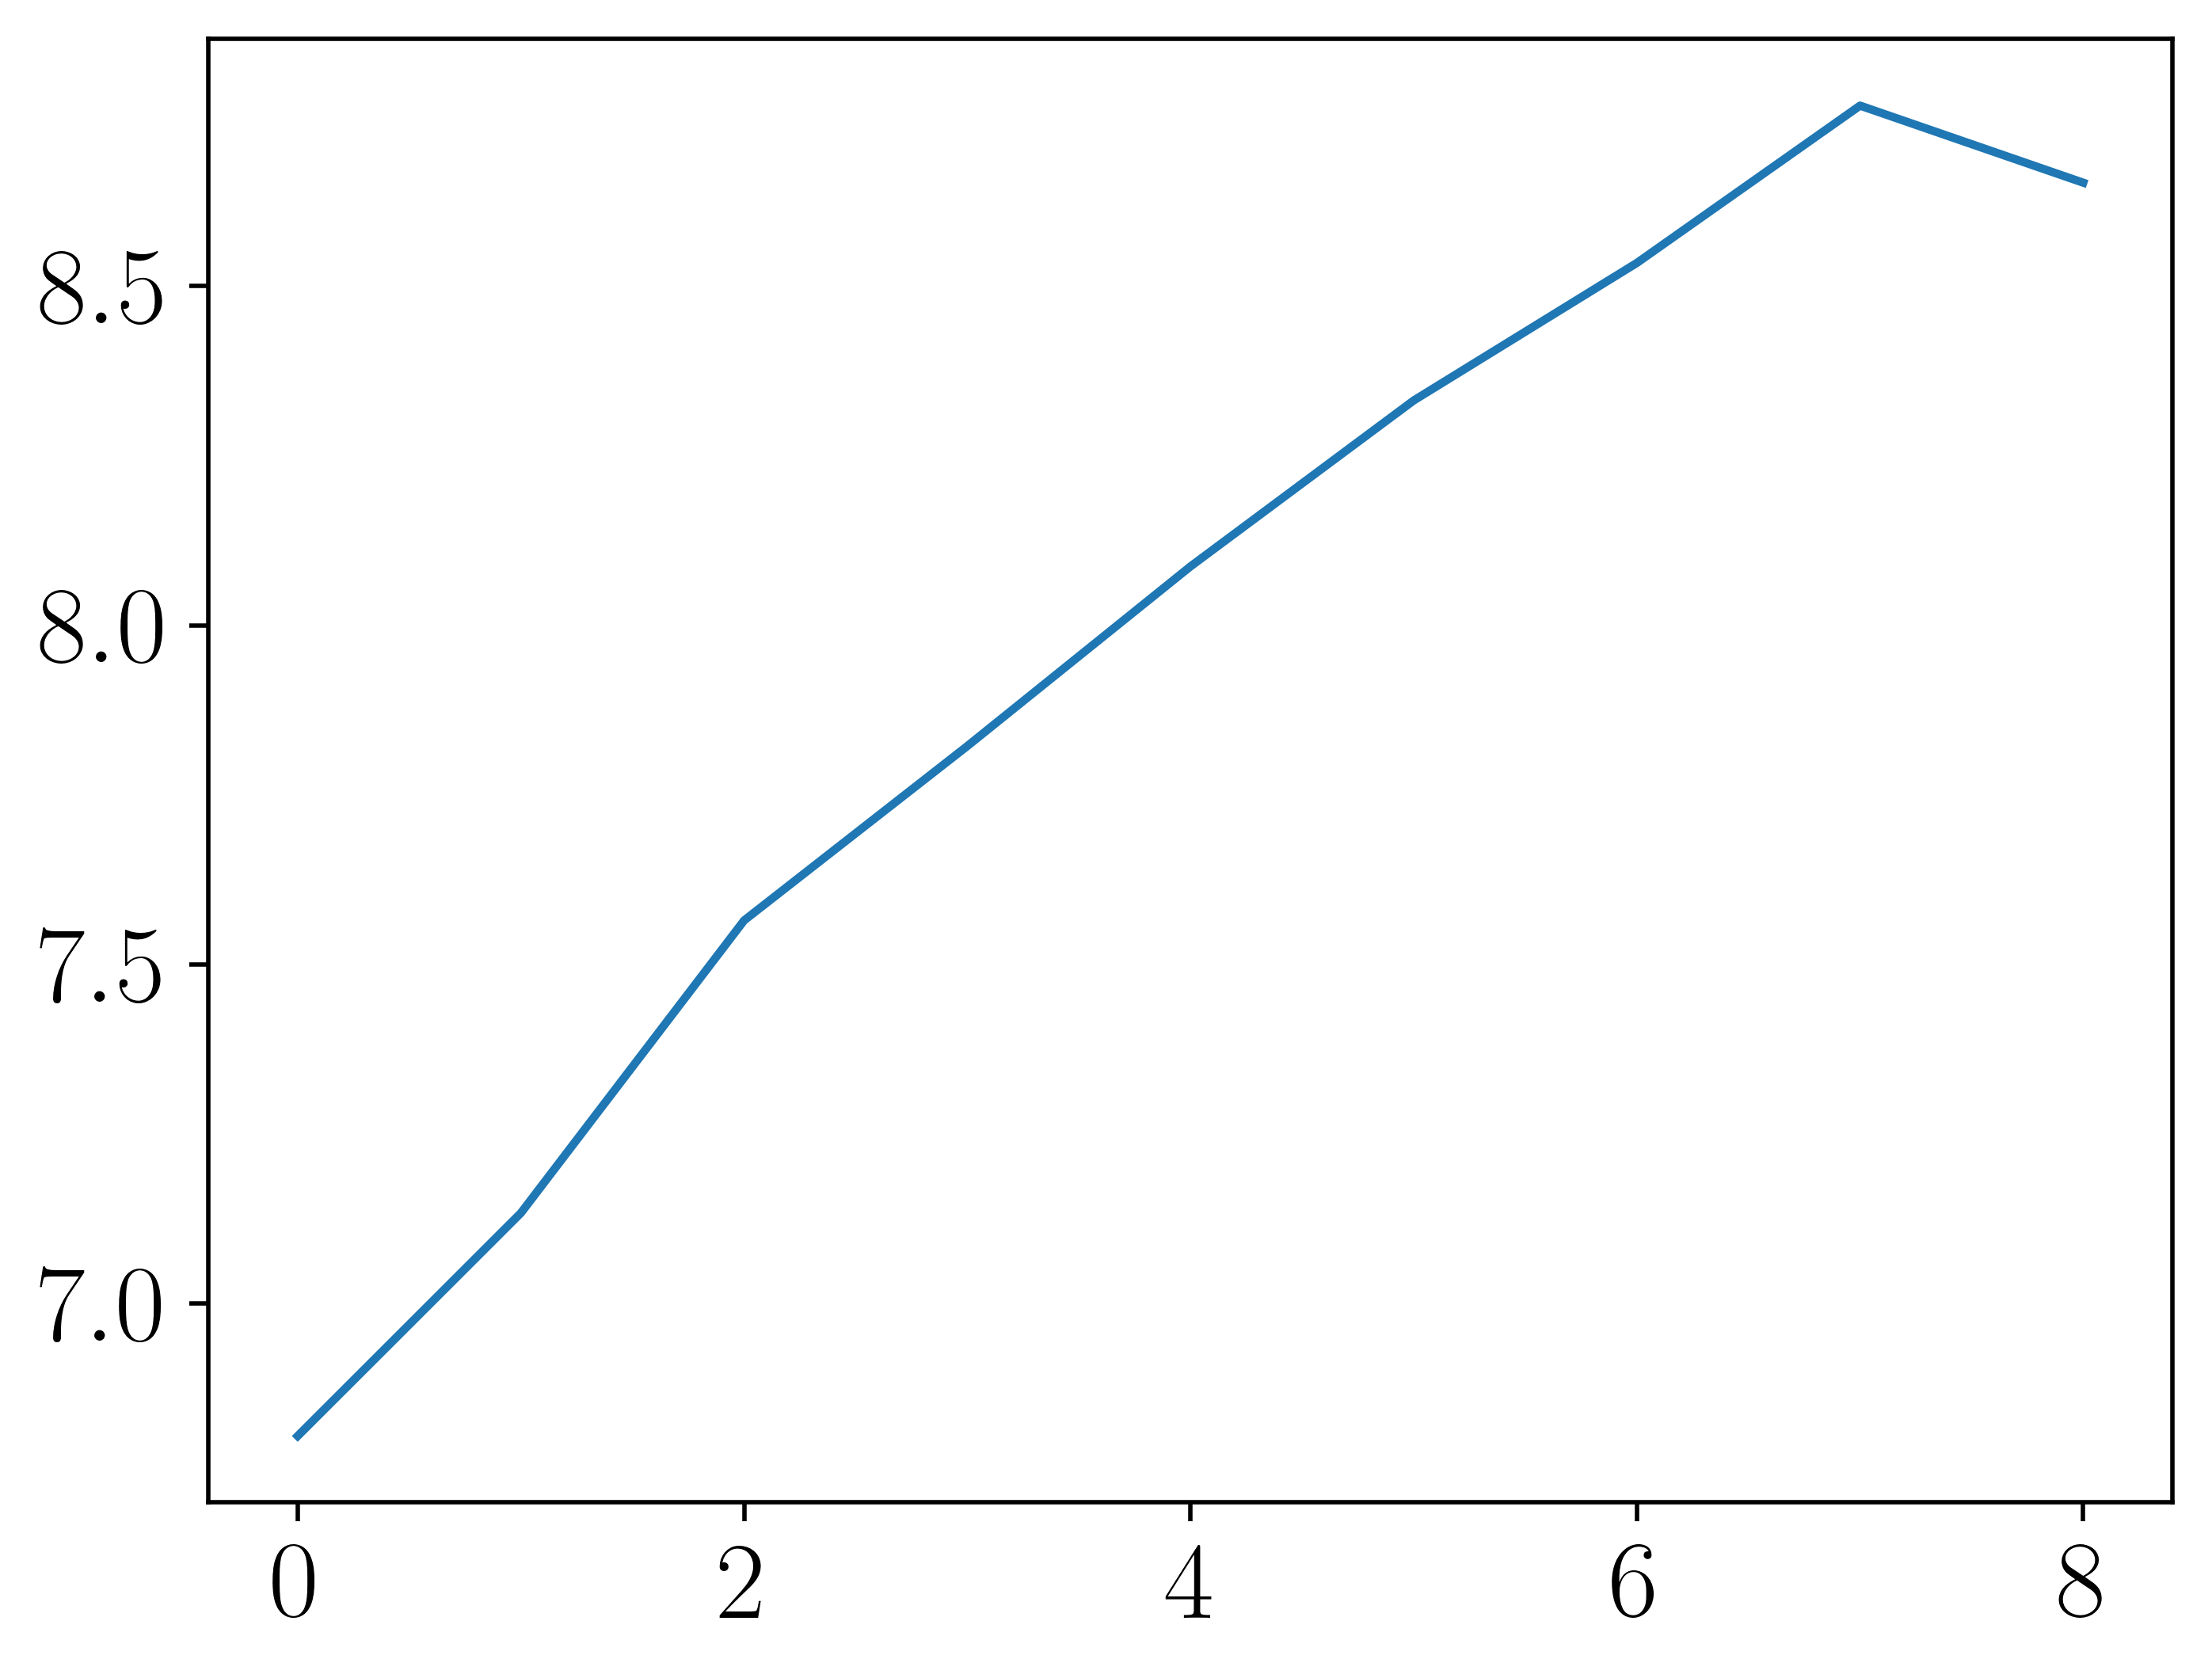

In [80]:
plt.plot(T_total-wrf_thr[subset_indices]/1e3)

In [77]:
wrf_T_total

array([691.83152737, 708.37847526, 716.71152193, 720.18993631,
       722.91650975, 724.71543538, 725.54873116, 724.89080974,
       720.35904852])

In [48]:
wrf_thr[subset_indices]/1e3

array([685.0263125, 701.244625 , 709.1465625, 712.368    , 714.8298125,
       716.3841875, 717.01475  , 716.125    , 711.7068125])

In [145]:
t_per_error = postproc.per_error(T_total, wrf_thr[subset_indices]/1e3)

p_per_error = postproc.per_error(P_total, wrf_pow[subset_indices]/1e6)

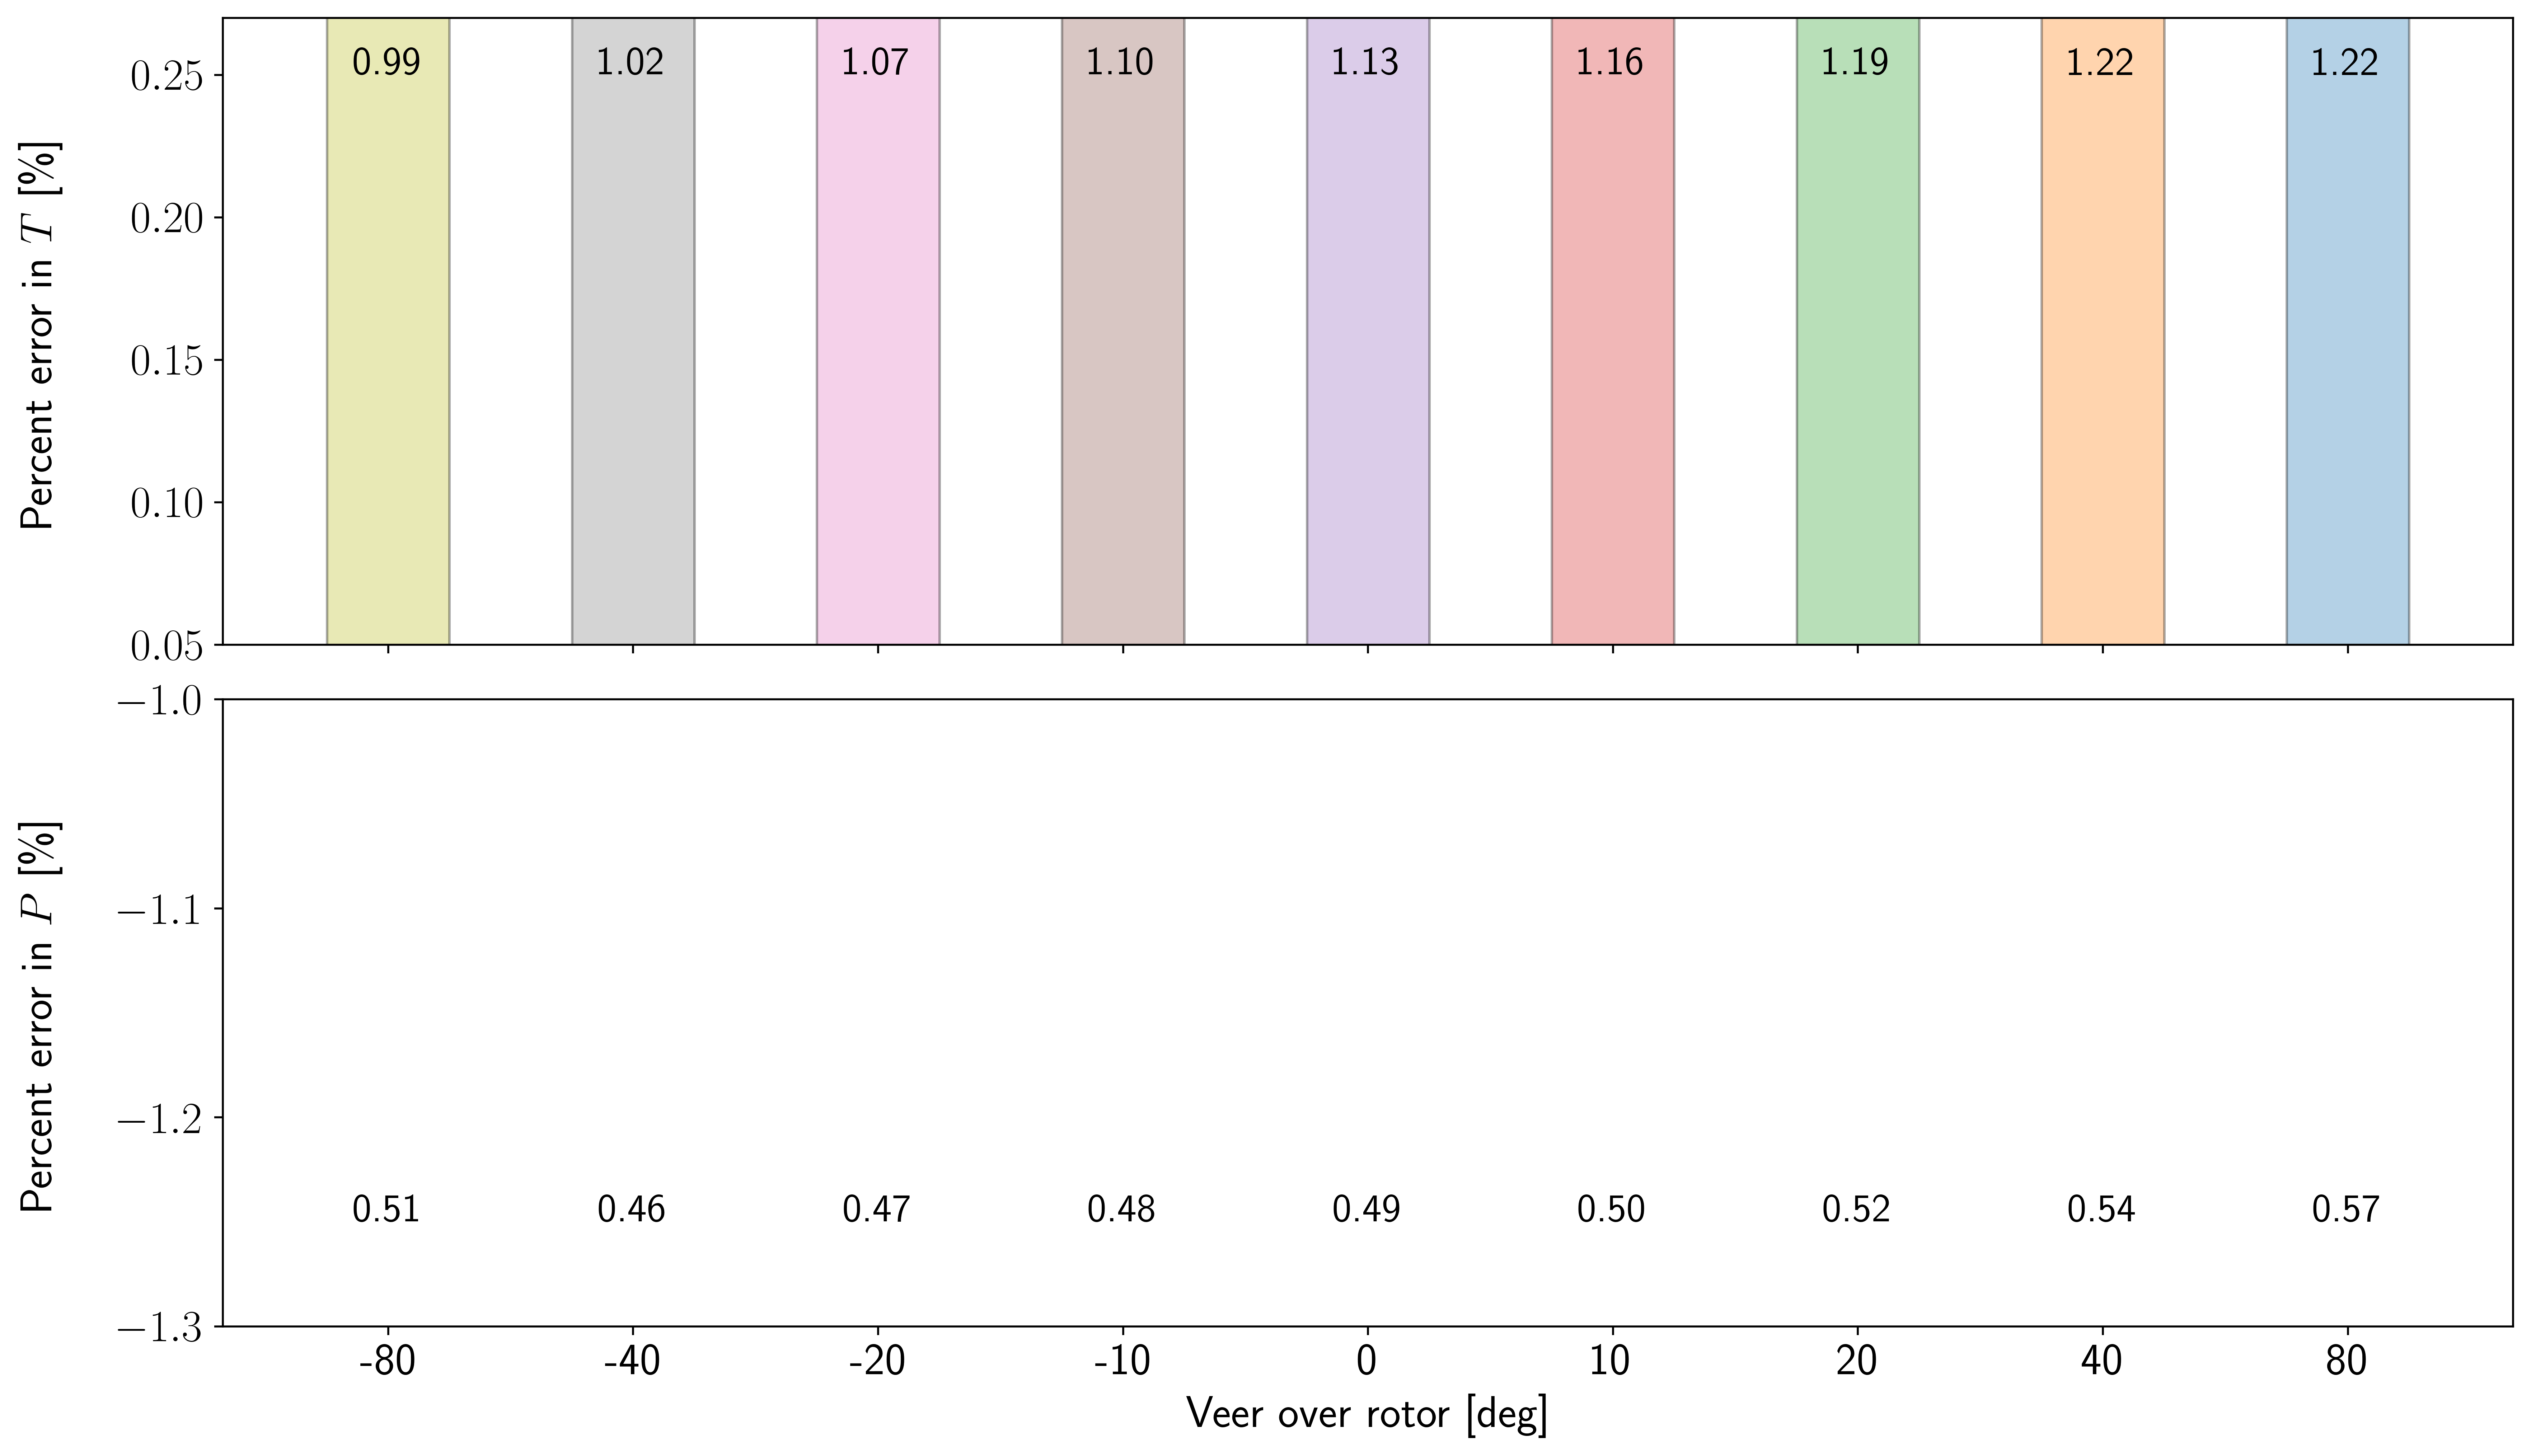

In [146]:
# Dimensional
colors = sns.color_palette("tab10", 9)

width = 0.5
alpha = 1/3
fontsize = 18
labfontsize = 16

full_colors = colors[::-1]

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Thrust

    ax[0].bar(ind[count], t_per_error[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)

    ax[0].text(ind[count], 0.25,
               f'{(t_per_error[count]):0.2f}%', ha='center', fontsize=labfontsize)
    
        
    
    ax[0].set_ylabel(r'Percent error in $T$ [\%]', fontsize=fontsize)
    ax[0].set_ylim([0.05, 0.27])

    # --- Power
    ax[1].bar(ind[count], p_per_error[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    

    ax[1].text(ind[count], -1.25,
               f'{(p_per_error[count]):0.2f}%', ha='center', fontsize=labfontsize)


    
    ax[1].set_ylabel(r'Percent error in $P$ [\%]', fontsize=fontsize)
    ax[1].set_ylim([-1.3, -1])

# Final formatting
ax[1].set_xticks(ind)

xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax[1].set_xticklabels(xaxislabels, fontsize=fontsize)
ax[1].set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax[1].tick_params(axis='x', rotation=0)

for axs in ax.flat:
    axs.tick_params(axis='y', labelsize=fontsize)

# Move y-labels to same horizontal position (x=-0.15 in axes coords)
for a in ax:
    a.yaxis.set_label_coords(-0.07, 0.5)  # (x, y) in axes coordinates

# Define custom legend handles
legend_handles = [
    Patch(facecolor='w', edgecolor='black', label='BE Model'),  # Replace 'gray' with any color you'd like to represent MIT
    Patch(facecolor='w', edgecolor='black', hatch='//', label='LES')  # Same for LES
]

plt.show()

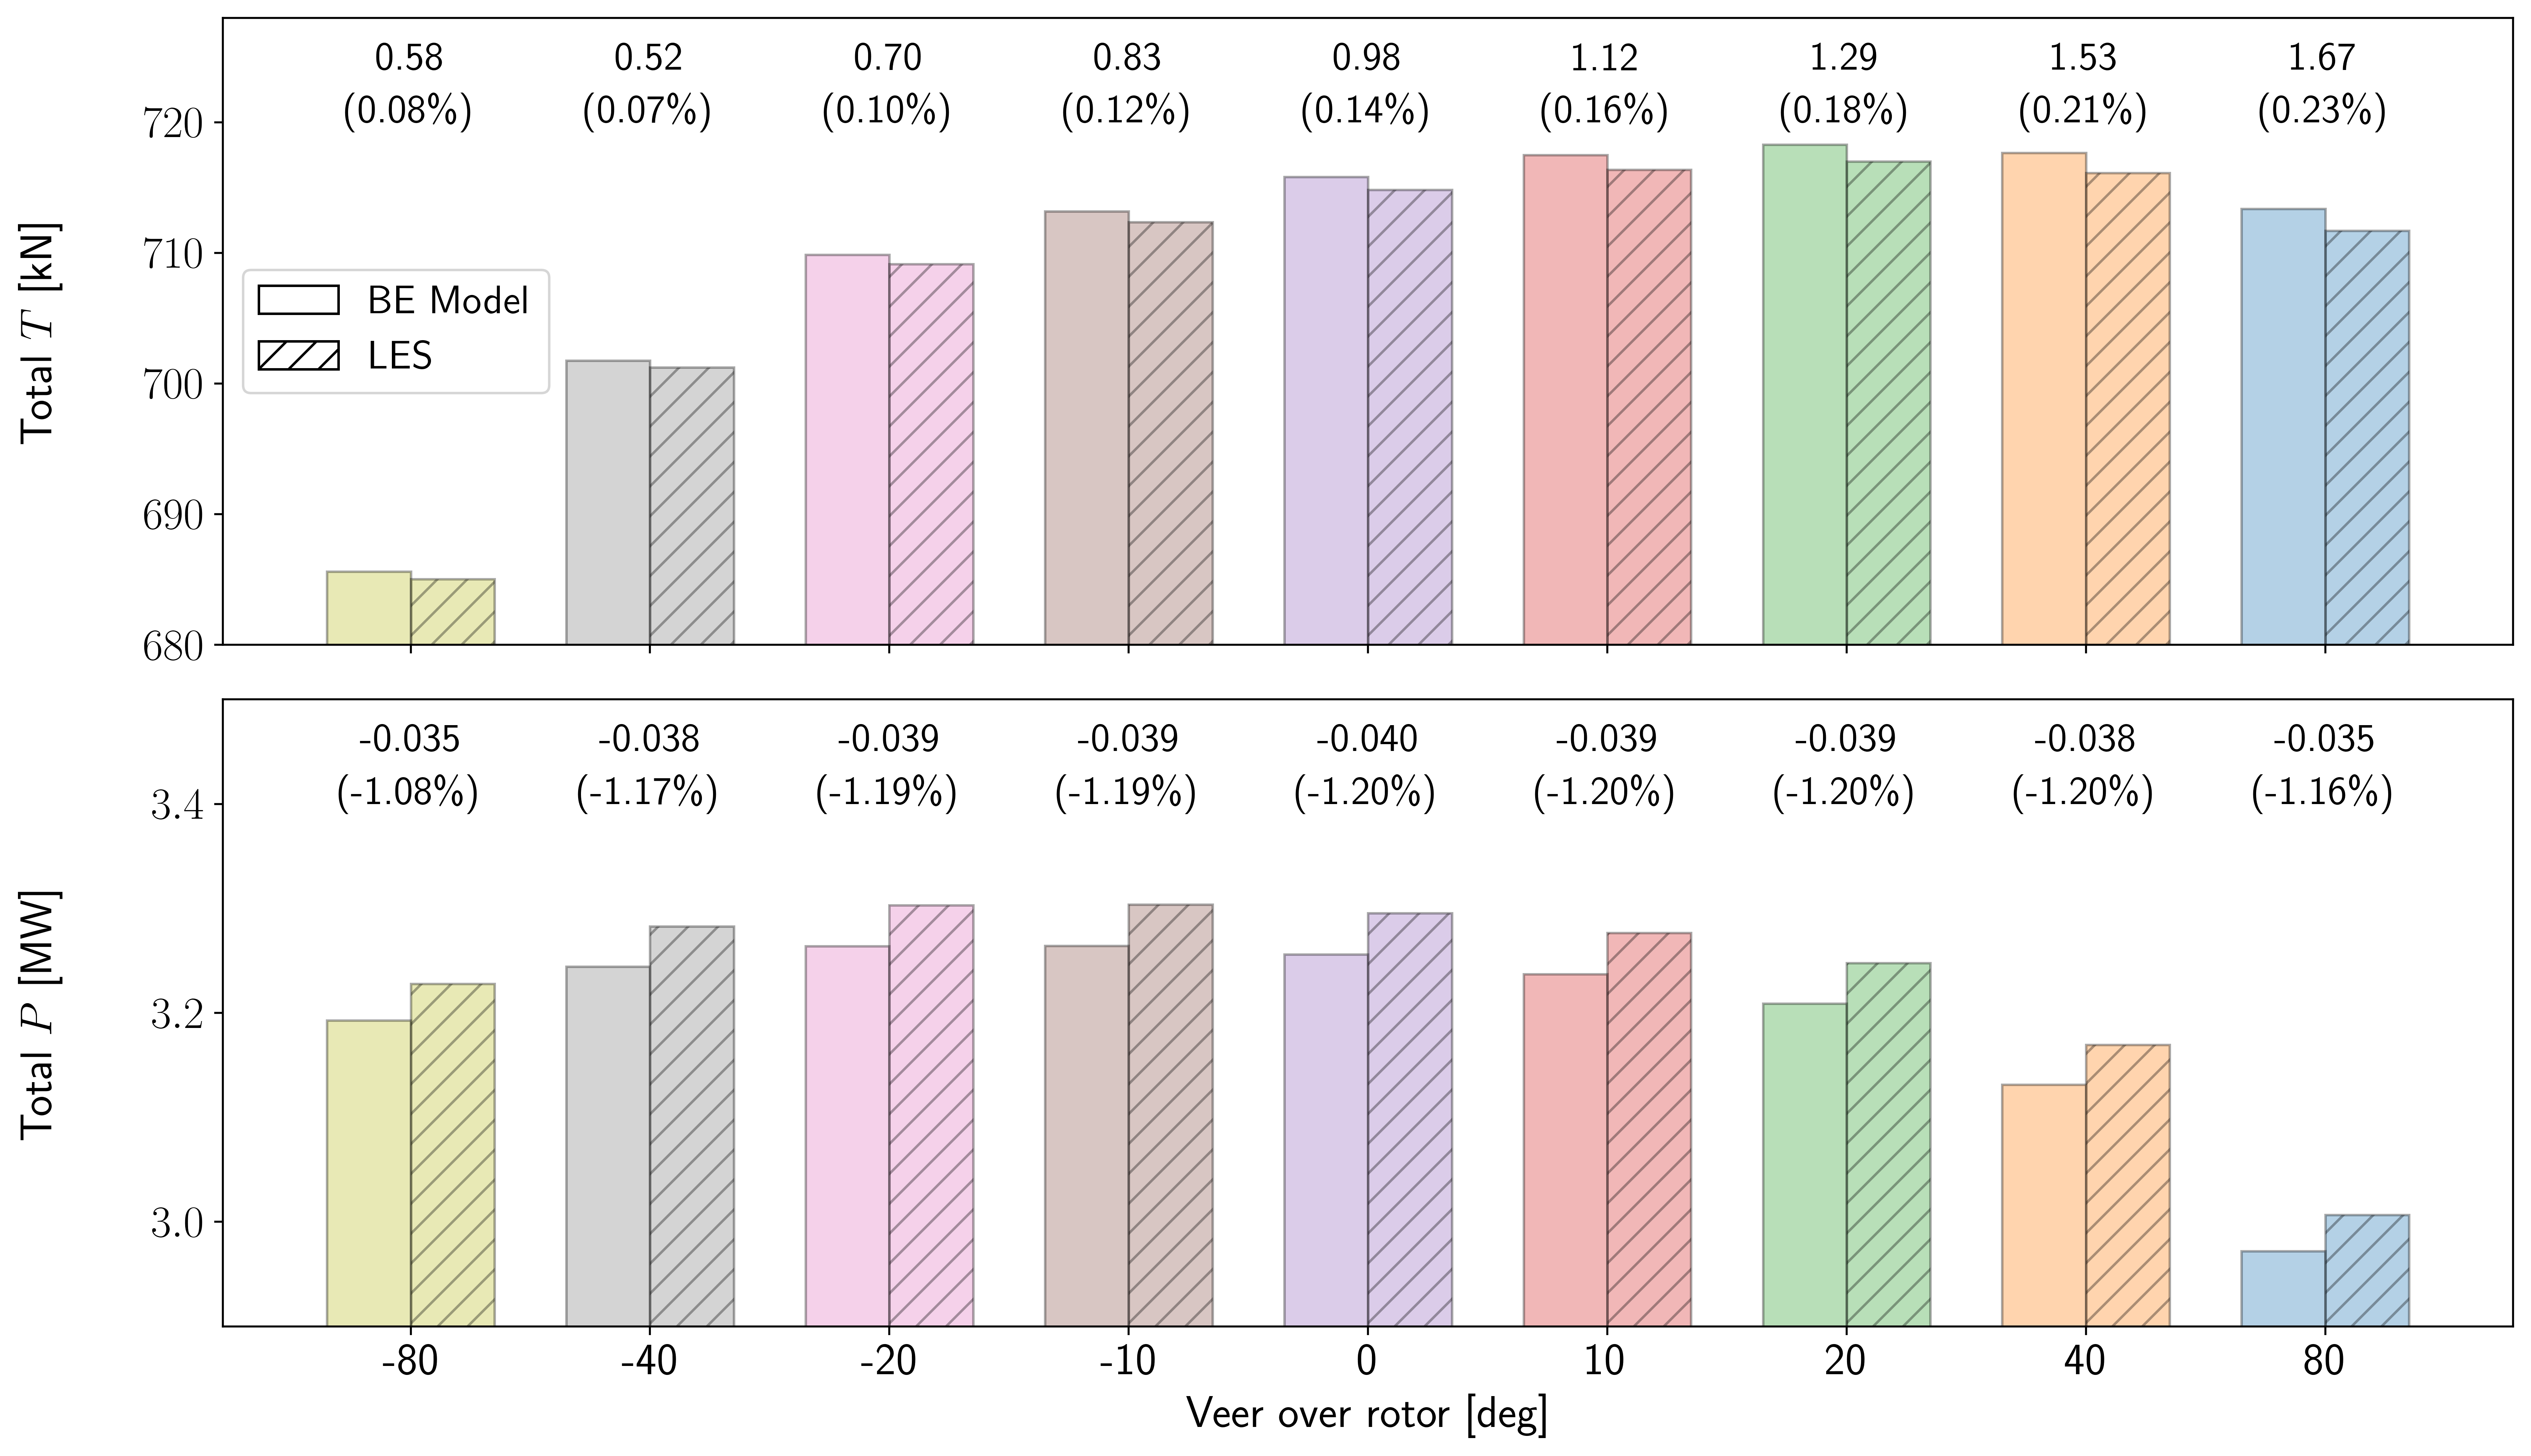

In [31]:
# Dimensional
colors = sns.color_palette("tab10", 9)

width = 0.35
alpha = 1/3
fontsize = 18
labfontsize = 16

full_colors = colors[::-1]

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Thrust

    ax[0].bar(ind[count] - width/2, T_total[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[0].bar(ind[count] + width/2, wrf_thr[subset_indices[count]]/1e3, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    # ax[0].text(ind[count] - width/2, 725,
    #            f'{T_total[count]:0.1f}%', ha='center', fontsize=labfontsize)
    
    # ax[0].text(ind[count] + width/2, 725,
    #            f'{wrf_thr[subset_indices[count]]/1e3:0.1f}%', ha='center', fontsize=labfontsize)



    ax[0].text(ind[count], 724,
               f'{(T_total[count] - wrf_thr[subset_indices[count]]/1e3):0.2f}', ha='center', fontsize=labfontsize)
    ax[0].text(ind[count], 720,
            f'({t_per_error[count]:0.2f}\%)', ha='center', fontsize=labfontsize)
        
    
    ax[0].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize)
    ax[0].set_ylim([680, 728])

    # --- Power
    ax[1].bar(ind[count] - width/2, P_total[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_pow[subset_indices[count]]/1e6, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    # ax[1].text(ind[count] - width/2, 3.4,
    #            f'{P_total[count]:0.2f}%', ha='center', fontsize=labfontsize)
    
    # ax[1].text(ind[count] + width/2, 3.4,
    #            f'{wrf_pow[subset_indices[count]]/1e6:0.2f}%', ha='center', fontsize=labfontsize)
    

    ax[1].text(ind[count], 3.45,
               f'{(P_total[count] - wrf_pow[subset_indices[count]]/1e6):0.3f}', ha='center', fontsize=labfontsize)
    ax[1].text(ind[count], 3.4,
            f'({p_per_error[count]:0.2f}\%)', ha='center', fontsize=labfontsize)

    
    ax[1].set_ylabel(r'Total $P$ [MW]', fontsize=fontsize)
    ax[1].set_ylim([2.9, 3.5])

# Final formatting
ax[1].set_xticks(ind)

xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax[1].set_xticklabels(xaxislabels, fontsize=fontsize)
ax[1].set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax[1].tick_params(axis='x', rotation=0)

for axs in ax.flat:
    axs.tick_params(axis='y', labelsize=fontsize)

# Move y-labels to same horizontal position (x=-0.15 in axes coords)
for a in ax:
    a.yaxis.set_label_coords(-0.07, 0.5)  # (x, y) in axes coordinates

# Define custom legend handles
legend_handles = [
    Patch(facecolor='w', edgecolor='black', label='BE Model'),  # Replace 'gray' with any color you'd like to represent MIT
    Patch(facecolor='w', edgecolor='black', hatch='//', label='LES')  # Same for LES
]

# Add legend to the top plot
ax[0].legend(handles=legend_handles, fontsize=labfontsize, loc='center left')

plt.show()

## Lift error

In [17]:
rotor = IEA10MW()

mit_ind = np.zeros_like(subset_indices, dtype='float')
mit_cot = np.zeros_like(subset_indices, dtype='float')
mit_thr = np.zeros_like(subset_indices, dtype='float')
mit_cop = np.zeros_like(subset_indices, dtype='float')
mit_pow = np.zeros_like(subset_indices, dtype='float')
iters   = np.zeros_like(subset_indices, dtype='float')

mit_w   = np.zeros_like(subset_indices, dtype='float')
mit_cax = np.zeros_like(subset_indices, dtype='float')
mit_vax = np.zeros_like(subset_indices, dtype='float')
mit_vtn = np.zeros_like(subset_indices, dtype='float')

T_total = np.zeros_like(subset_indices, dtype='float')
P_total = np.zeros_like(subset_indices, dtype='float')

Nr = 26
NSct = 158

for count in range(len(subset_indices)):

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nr,Ntheta=Nsct), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0.0), tangential_induction_model=NoTangentialInduction(),index = subset_indices[count])

    tsr = wrf_tsr[subset_indices[count]]

    rotor_U = (u[:,:,subset_indices[count]]**2 + v[:,:,subset_indices[count]]**2)**(1/2)

    rotor_dir = np.atan2(v[:,:,subset_indices[count]], u[:,:,subset_indices[count]])

    sol = bem(0, tsr, 0, U = rotor_U/Uhub[subset_indices[count]], wdir=rotor_dir, index = subset_indices[count])

    rho = 1.225

    r = rOverR * rotor.R
    # r = sol.geom.mu * rotor.R

    dr = (rotor.R - rotor.hub_radius)/Nelm

    dtheta = 2 * np.pi / Nsct

    chord = np.array([4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734])
    rho = 1.225

    Vrel = np.sqrt((sol.Vax('sector'))**2 + sol.Vtan('sector')**2) * Uhub[subset_indices[count]]
    phi = sol.phi('sector')

    L = wrf_L[:,:,subset_indices[count]].T
    D = wrf_D[:,:,subset_indices[count]].T

    # phi = wrf_phi[:,:,subset_indices[count]]

    FT = L.T * np.sin(phi) - D.T * np.cos(phi)
    FN = L.T * np.cos(phi) + D.T * np.sin(phi)

    sigma = 3/Nsct

    T = FN * dr * sigma

    P = FT.T * r * dr * sigma * wrf_omg[subset_indices[count]] * 2 * np.pi / 60

    T_total[count] = np.sum(T)/1e3
    P_total[count] = np.sum(P)/1e6

    mit_cot[count] = sol.Ct()
    mit_cop[count] = sol.Cp()
    iters[count] = sol.niter

iters

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [18]:
lift_t_err = T_total - wrf_thr[subset_indices]/1e3

lift_p_err = P_total - wrf_pow[subset_indices]/1e6

In [19]:
t_per_error = postproc.per_error(T_total, wrf_thr[subset_indices]/1e3)

p_per_error = postproc.per_error(P_total, wrf_pow[subset_indices]/1e6)

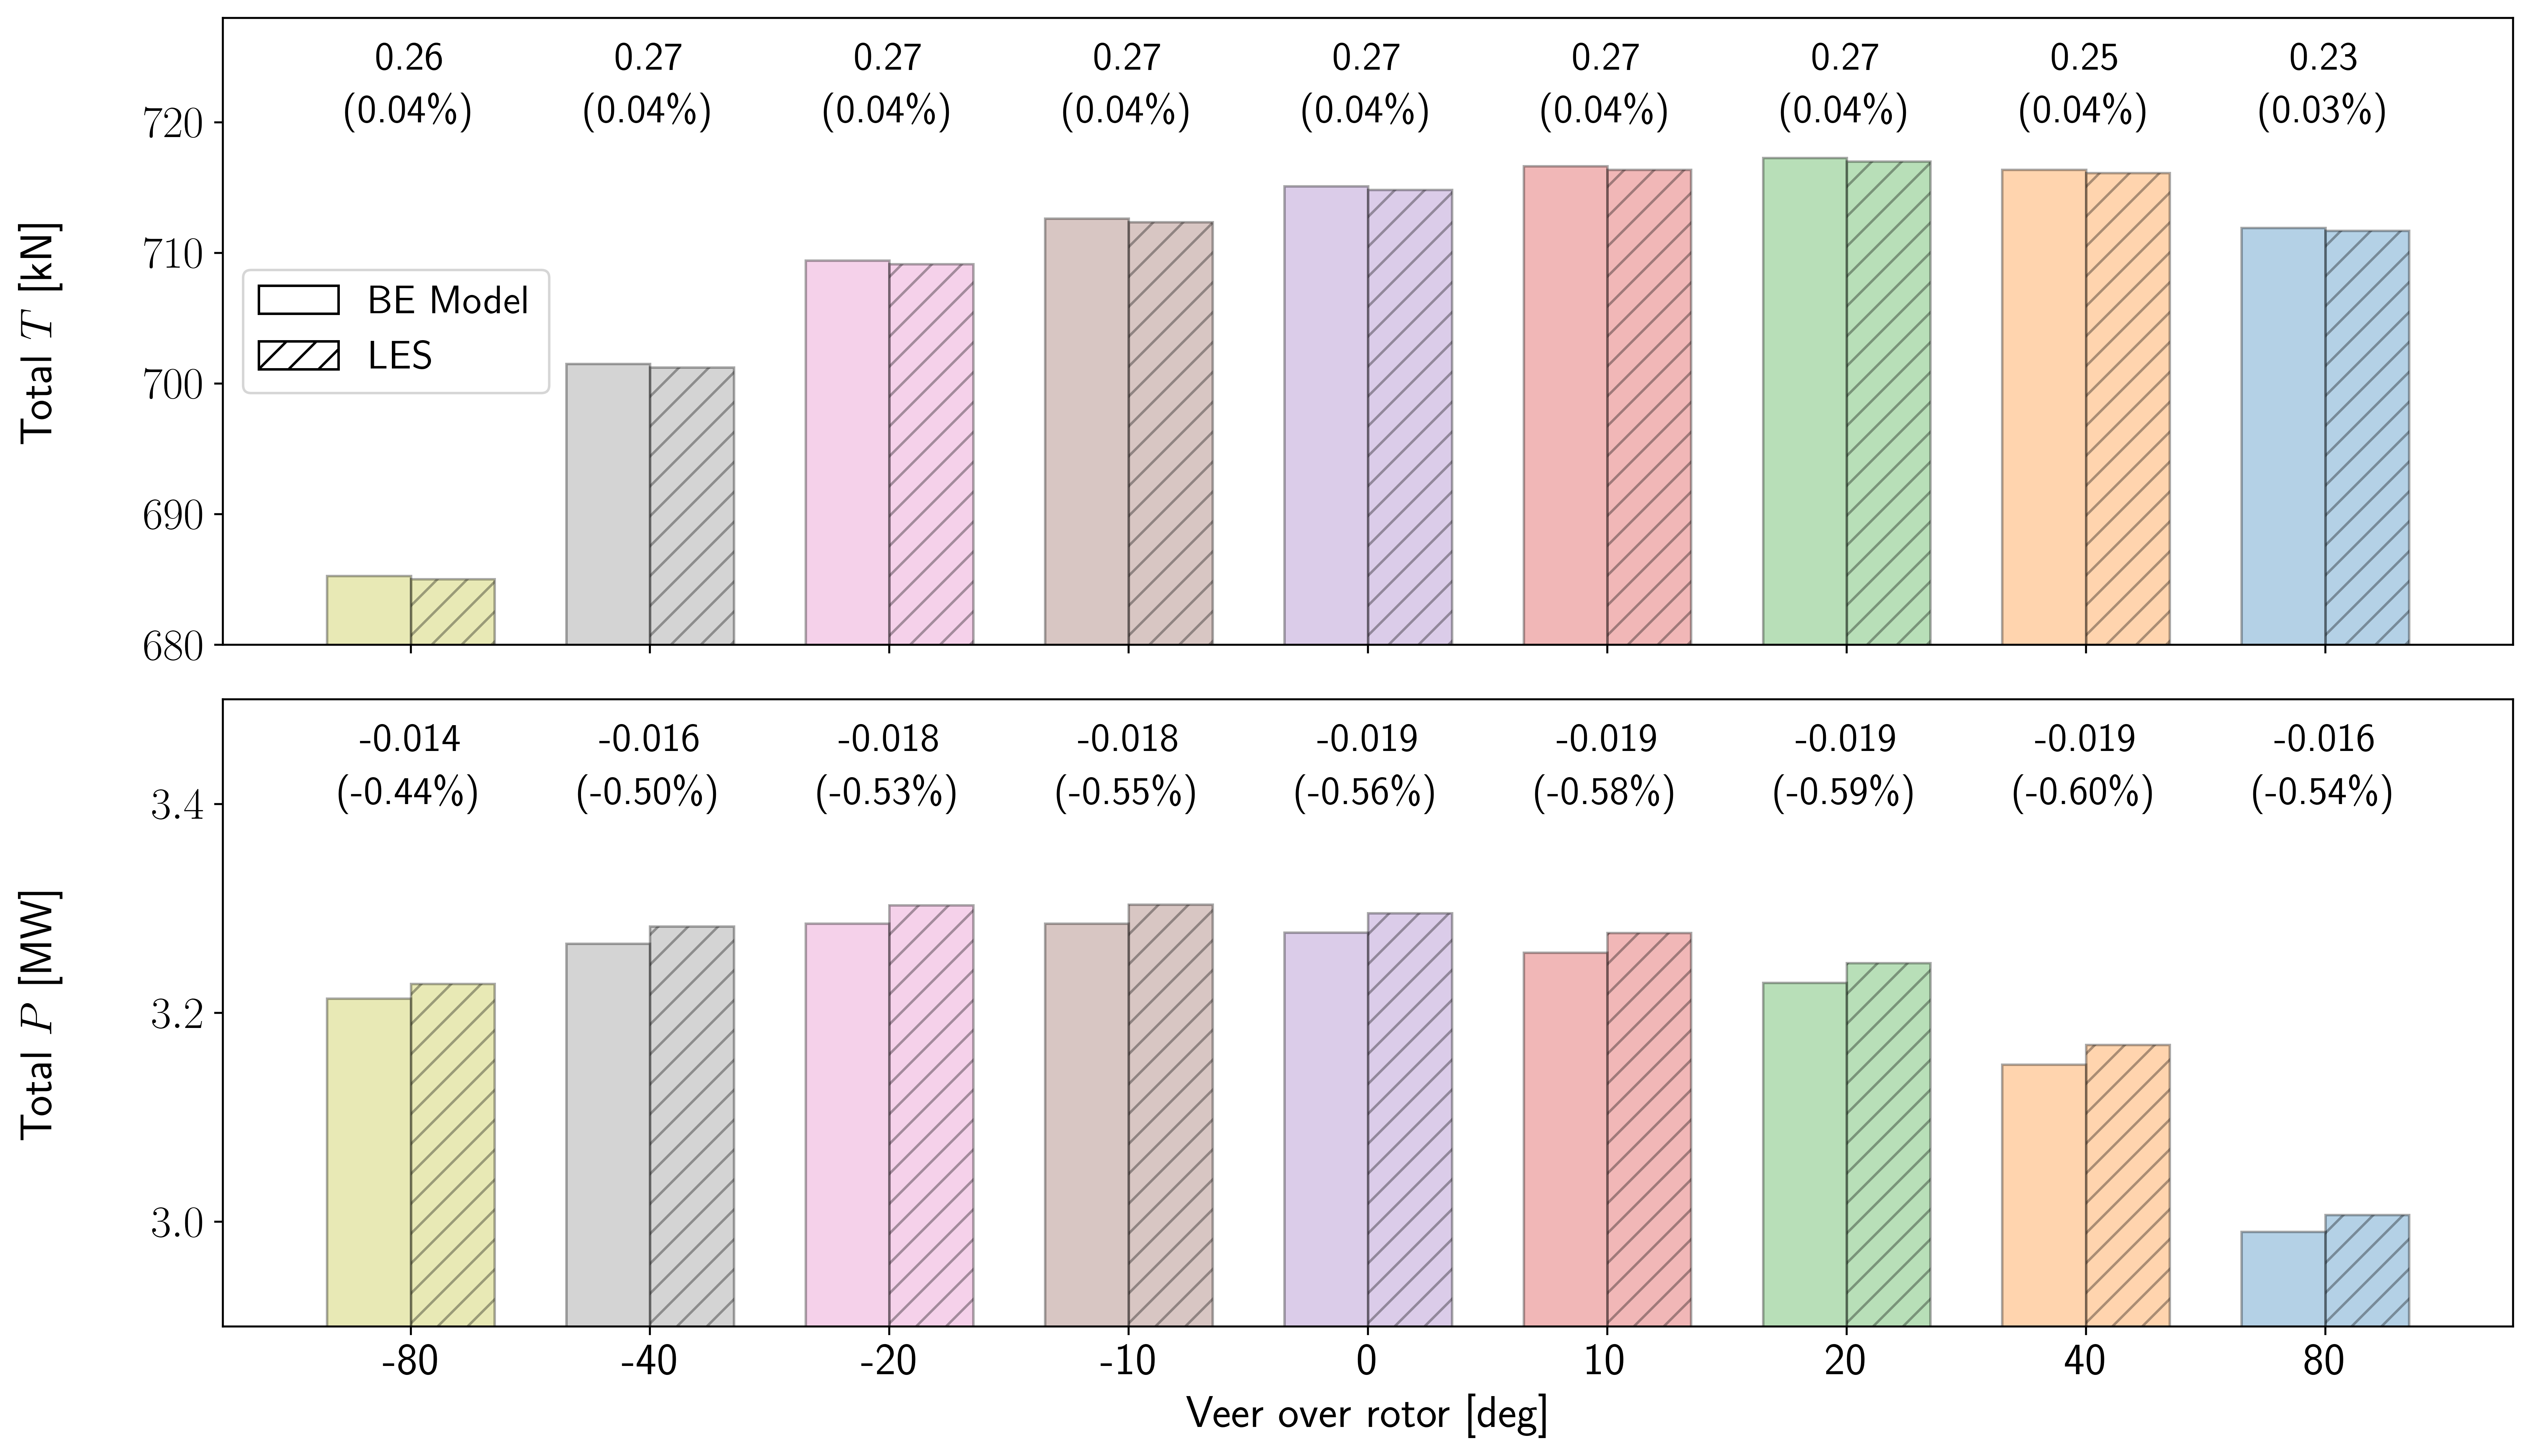

In [20]:
# Dimensional
colors = sns.color_palette("tab10", 9)

width = 0.35
alpha = 1/3
fontsize = 18
labfontsize = 16

full_colors = colors[::-1]

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Thrust

    ax[0].bar(ind[count] - width/2, T_total[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[0].bar(ind[count] + width/2, wrf_thr[subset_indices[count]]/1e3, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    # ax[0].text(ind[count] - width/2, 725,
    #            f'{T_total[count]:0.1f}%', ha='center', fontsize=labfontsize)
    
    # ax[0].text(ind[count] + width/2, 725,
    #            f'{wrf_thr[subset_indices[count]]/1e3:0.1f}%', ha='center', fontsize=labfontsize)



    ax[0].text(ind[count], 724,
               f'{(T_total[count] - wrf_thr[subset_indices[count]]/1e3):0.2f}', ha='center', fontsize=labfontsize)
    ax[0].text(ind[count], 720,
            f'({t_per_error[count]:0.2f}\%)', ha='center', fontsize=labfontsize)
        
    
    ax[0].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize)
    ax[0].set_ylim([680, 728])

    # --- Power
    ax[1].bar(ind[count] - width/2, P_total[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_pow[subset_indices[count]]/1e6, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    # ax[1].text(ind[count] - width/2, 3.4,
    #            f'{P_total[count]:0.2f}%', ha='center', fontsize=labfontsize)
    
    # ax[1].text(ind[count] + width/2, 3.4,
    #            f'{wrf_pow[subset_indices[count]]/1e6:0.2f}%', ha='center', fontsize=labfontsize)
    

    ax[1].text(ind[count], 3.45,
               f'{(P_total[count] - wrf_pow[subset_indices[count]]/1e6):0.3f}', ha='center', fontsize=labfontsize)
    ax[1].text(ind[count], 3.4,
            f'({p_per_error[count]:0.2f}\%)', ha='center', fontsize=labfontsize)

    
    ax[1].set_ylabel(r'Total $P$ [MW]', fontsize=fontsize)
    ax[1].set_ylim([2.9, 3.5])

# Final formatting
ax[1].set_xticks(ind)

xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax[1].set_xticklabels(xaxislabels, fontsize=fontsize)
ax[1].set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax[1].tick_params(axis='x', rotation=0)

for axs in ax.flat:
    axs.tick_params(axis='y', labelsize=fontsize)

# Move y-labels to same horizontal position (x=-0.15 in axes coords)
for a in ax:
    a.yaxis.set_label_coords(-0.07, 0.5)  # (x, y) in axes coordinates

# Define custom legend handles
legend_handles = [
    Patch(facecolor='w', edgecolor='black', label='BE Model'),  # Replace 'gray' with any color you'd like to represent MIT
    Patch(facecolor='w', edgecolor='black', hatch='//', label='LES')  # Same for LES
]

# Add legend to the top plot
ax[0].legend(handles=legend_handles, fontsize=labfontsize, loc='center left')

plt.show()

In [21]:
rotor = IEA10MW()

mit_ind = np.zeros_like(subset_indices, dtype='float')
mit_cot = np.zeros_like(subset_indices, dtype='float')
mit_thr = np.zeros_like(subset_indices, dtype='float')
mit_cop = np.zeros_like(subset_indices, dtype='float')
mit_pow = np.zeros_like(subset_indices, dtype='float')
iters   = np.zeros_like(subset_indices, dtype='float')

mit_w   = np.zeros_like(subset_indices, dtype='float')
mit_cax = np.zeros_like(subset_indices, dtype='float')
mit_vax = np.zeros_like(subset_indices, dtype='float')
mit_vtn = np.zeros_like(subset_indices, dtype='float')

T_total = np.zeros_like(subset_indices, dtype='float')
P_total = np.zeros_like(subset_indices, dtype='float')

Nr = 26
NSct = 158

for count in range(len(subset_indices)):

    bem = BEM(rotor=rotor, geometry=BEMGeometry(Nr=Nr,Ntheta=Nsct), aerodynamic_model=KraghAerodynamics(), tiploss_model=NoTipLoss(), momentum_model=ConstantInduction(a=0.0), tangential_induction_model=NoTangentialInduction(),index = subset_indices[count])

    tsr = wrf_tsr[subset_indices[count]]

    rotor_U = (u[:,:,subset_indices[count]]**2 + v[:,:,subset_indices[count]]**2)**(1/2)

    rotor_dir = np.atan2(v[:,:,subset_indices[count]], u[:,:,subset_indices[count]])

    sol = bem(0, tsr, 0, U = rotor_U/Uhub[subset_indices[count]], wdir=rotor_dir, index = subset_indices[count])

    rho = 1.225

    r = rOverR * rotor.R
    # r = sol.geom.mu * rotor.R

    dr = (rotor.R - rotor.hub_radius)/Nelm

    dtheta = 2 * np.pi / Nsct

    chord = np.array([4.649046,4.844576,5.216862,5.647547,5.931514,5.96353,5.812206,5.569981,5.273268,4.94348,4.598646,4.251929,3.911027,3.581805,3.269938,2.978544,2.70897,2.462014,2.237137,2.035348,1.855479,1.691271,1.526768,1.308778,0.7955106,0.5734])
    rho = 1.225

    Vrel = np.sqrt((sol.Vax('sector'))**2 + sol.Vtan('sector')**2) * Uhub[subset_indices[count]]

    # Vrel = wrf_W[:,:,subset_indices[count]]

    # L = 1/2 * rho * chord * (sol.Cl('sector') * Vrel**2).T
    # D = 1/2 * rho * chord * (sol.Cd('sector') * Vrel**2).T

    L = wrf_L[:,:,subset_indices[count]].T
    D = wrf_D[:,:,subset_indices[count]].T

    phi = wrf_phi[:,:,subset_indices[count]]

    FT = L.T * np.sin(phi) - D.T * np.cos(phi)
    FN = L.T * np.cos(phi) + D.T * np.sin(phi)

    sigma = 3/Nsct

    T = FN * dr * sigma

    P = FT.T * r * dr * sigma * wrf_omg[subset_indices[count]] * 2 * np.pi / 60

    T_total[count] = np.sum(T)/1e3
    P_total[count] = np.sum(P)/1e6

    mit_cot[count] = sol.Ct()
    mit_cop[count] = sol.Cp()
    iters[count] = sol.niter

iters

array([1., 1., 1., 1., 1., 1., 1., 1., 1.])

In [22]:
phi_t_err = T_total - wrf_thr[subset_indices]/1e3

phi_p_err = P_total - wrf_pow[subset_indices]/1e6

In [23]:
t_per_error = postproc.per_error(T_total, wrf_thr[subset_indices]/1e3)

p_per_error = postproc.per_error(P_total, wrf_pow[subset_indices]/1e6)

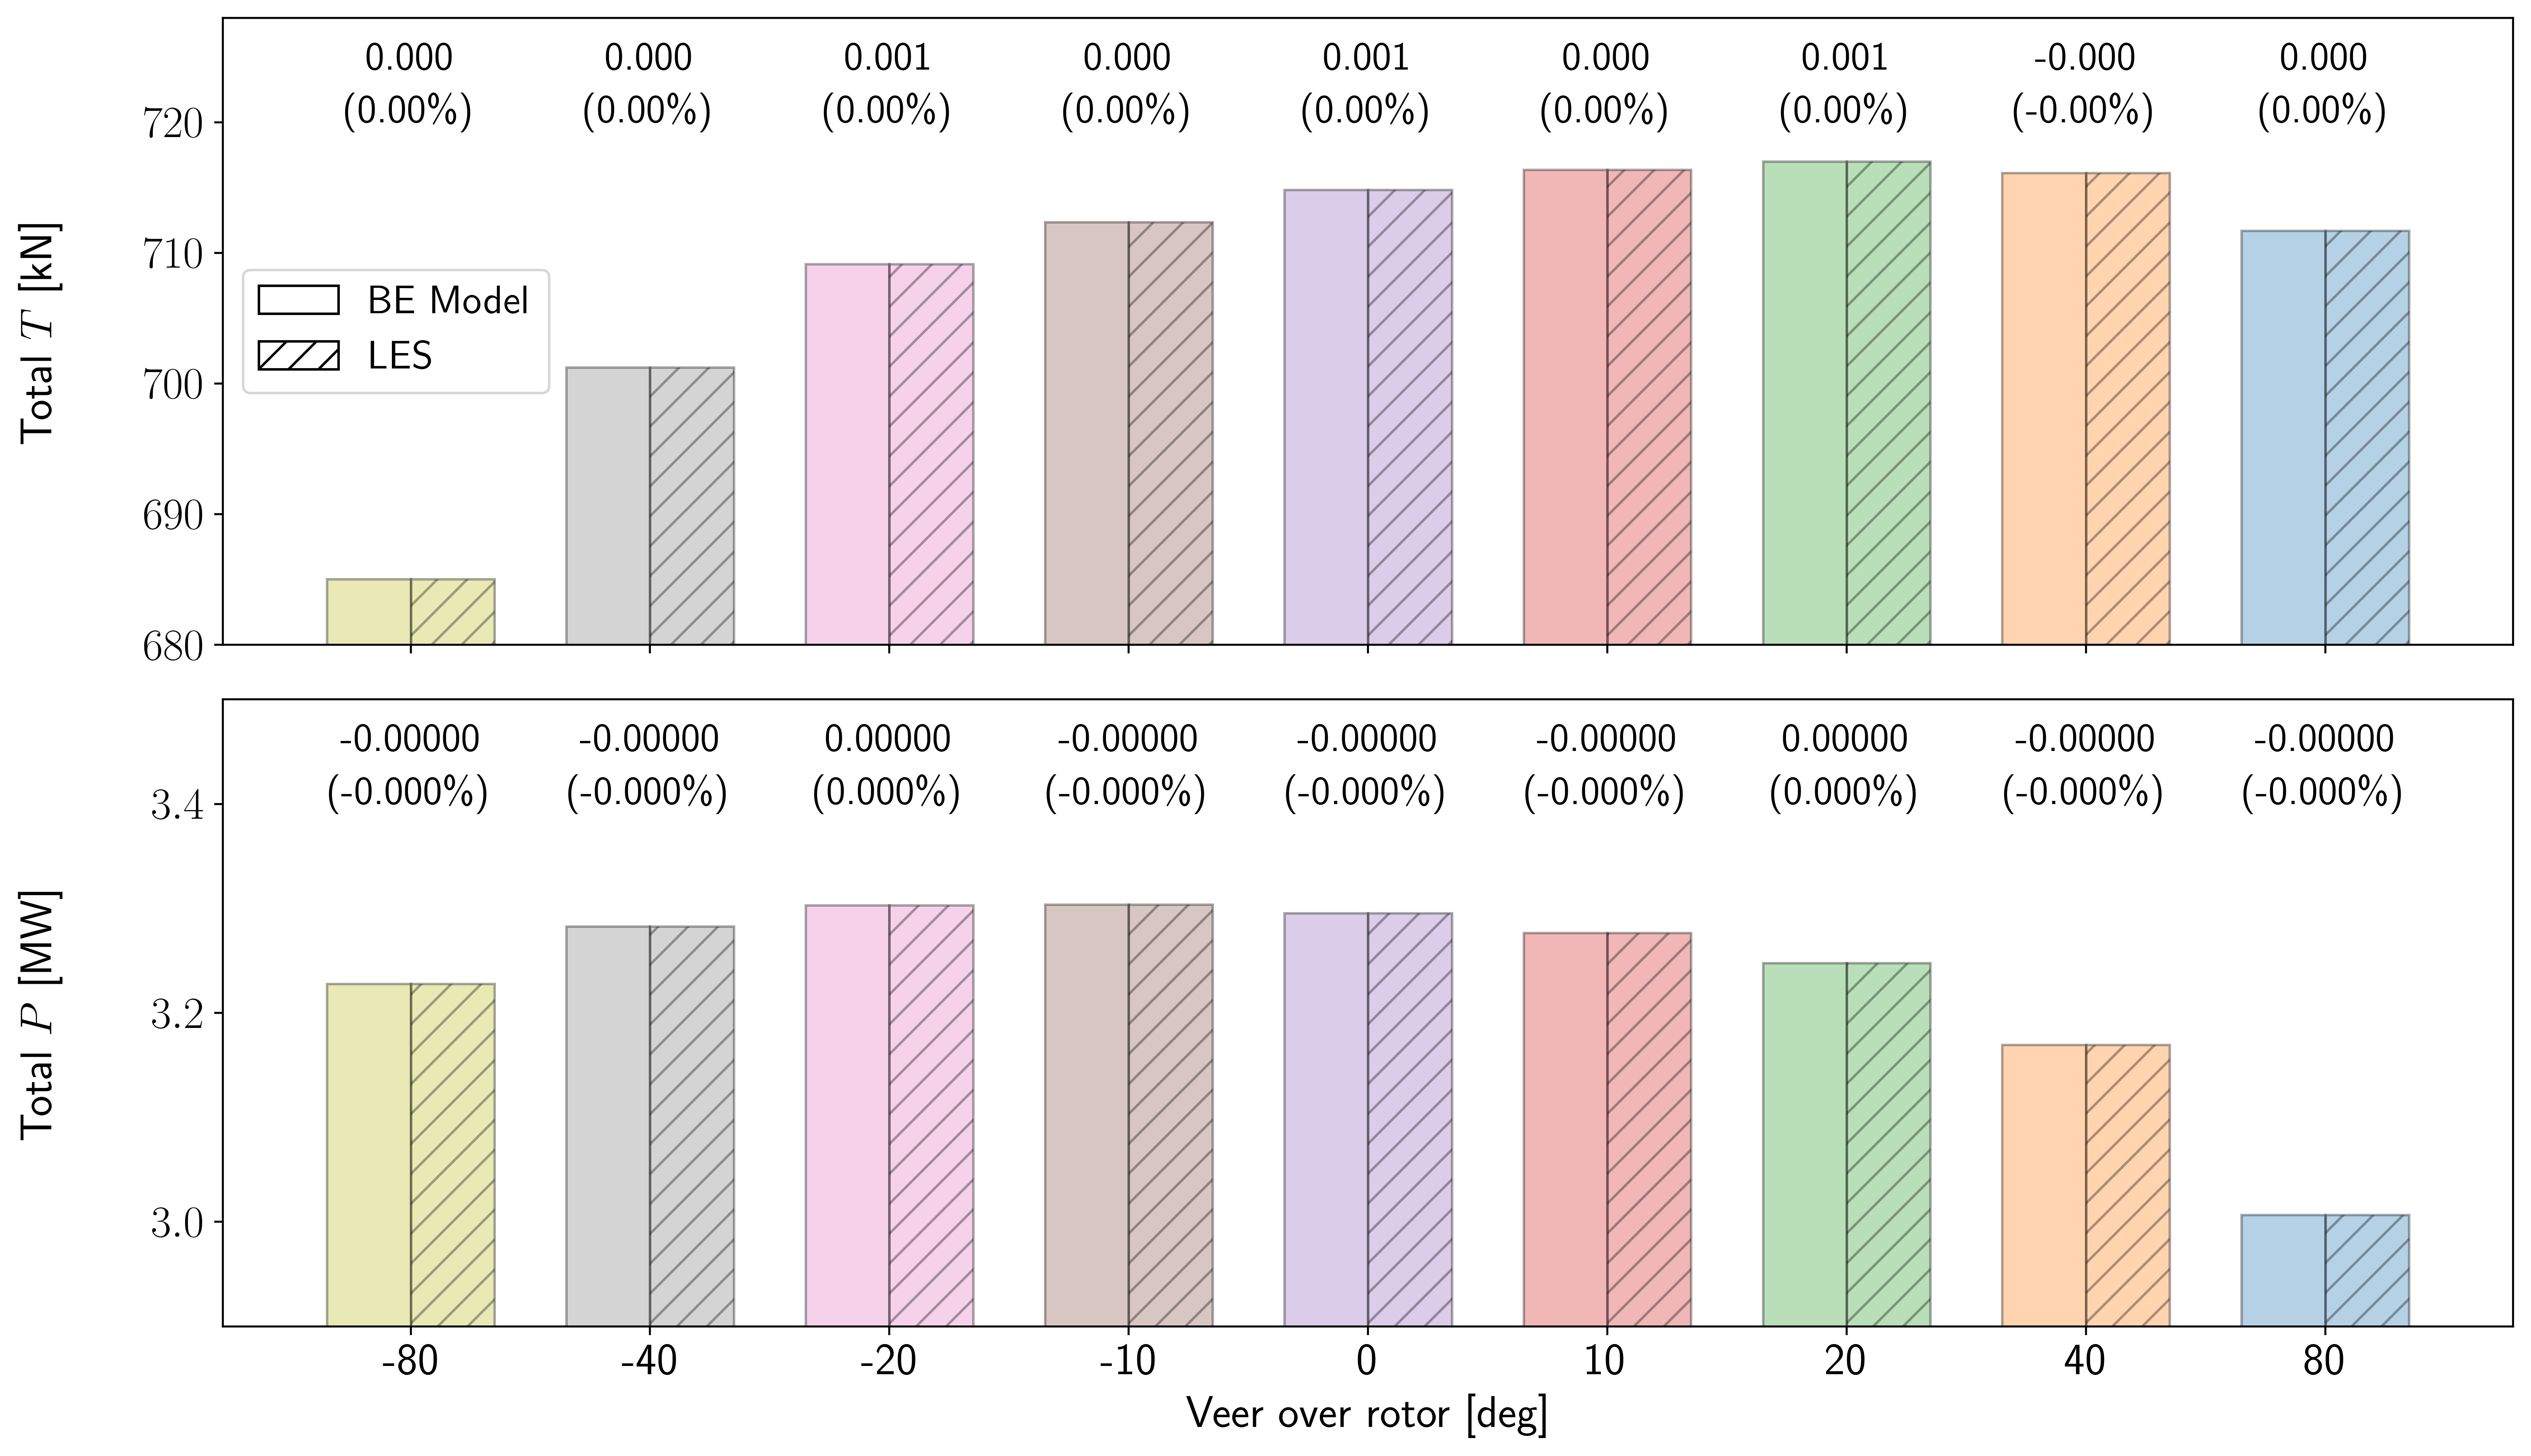

In [24]:
# Dimensional
colors = sns.color_palette("tab10", 9)

width = 0.35
alpha = 1/3
fontsize = 18
labfontsize = 16

full_colors = colors[::-1]

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(14, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(0, color='black', linestyle='solid', linewidth=1)

# Plotting
for count in range(len(new_names)):
    # --- Thrust

    ax[0].bar(ind[count] - width/2, T_total[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[0].bar(ind[count] + width/2, wrf_thr[subset_indices[count]]/1e3, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    # ax[0].text(ind[count] - width/2, 725,
    #            f'{T_total[count]:0.1f}%', ha='center', fontsize=labfontsize)
    
    # ax[0].text(ind[count] + width/2, 725,
    #            f'{wrf_thr[subset_indices[count]]/1e3:0.1f}%', ha='center', fontsize=labfontsize)



    ax[0].text(ind[count], 724,
               f'{(T_total[count] - wrf_thr[subset_indices[count]]/1e3):0.3f}', ha='center', fontsize=labfontsize)
    ax[0].text(ind[count], 720,
            f'({t_per_error[count]:0.2f}\%)', ha='center', fontsize=labfontsize)
        
    
    ax[0].set_ylabel(r'Total $T$ [kN]', fontsize=fontsize)
    ax[0].set_ylim([680, 728])

    # --- Power
    ax[1].bar(ind[count] - width/2, P_total[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha)
    
    ax[1].bar(ind[count] + width/2, wrf_pow[subset_indices[count]]/1e6, width,
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//')
    
    # ax[1].text(ind[count] - width/2, 3.4,
    #            f'{P_total[count]:0.2f}%', ha='center', fontsize=labfontsize)
    
    # ax[1].text(ind[count] + width/2, 3.4,
    #            f'{wrf_pow[subset_indices[count]]/1e6:0.2f}%', ha='center', fontsize=labfontsize)
    

    ax[1].text(ind[count], 3.45,
               f'{(P_total[count] - wrf_pow[subset_indices[count]]/1e6):0.5f}', ha='center', fontsize=labfontsize)
    ax[1].text(ind[count], 3.4,
            f'({p_per_error[count]:0.3f}\%)', ha='center', fontsize=labfontsize)

    
    ax[1].set_ylabel(r'Total $P$ [MW]', fontsize=fontsize)
    ax[1].set_ylim([2.9, 3.5])

# Final formatting
ax[1].set_xticks(ind)

xaxislabels = ['-80','-40','-20','-10','0','10','20','40','80']
ax[1].set_xticklabels(xaxislabels, fontsize=fontsize)
ax[1].set_xlabel('Veer over rotor [deg]',fontsize=fontsize)
ax[1].tick_params(axis='x', rotation=0)

for axs in ax.flat:
    axs.tick_params(axis='y', labelsize=fontsize)

# Move y-labels to same horizontal position (x=-0.15 in axes coords)
for a in ax:
    a.yaxis.set_label_coords(-0.07, 0.5)  # (x, y) in axes coordinates

# Define custom legend handles
legend_handles = [
    Patch(facecolor='w', edgecolor='black', label='BE Model'),  # Replace 'gray' with any color you'd like to represent MIT
    Patch(facecolor='w', edgecolor='black', hatch='//', label='LES')  # Same for LES
]

# Add legend to the top plot
ax[0].legend(handles=legend_handles, fontsize=labfontsize, loc='center left')

plt.show()

## Proportions

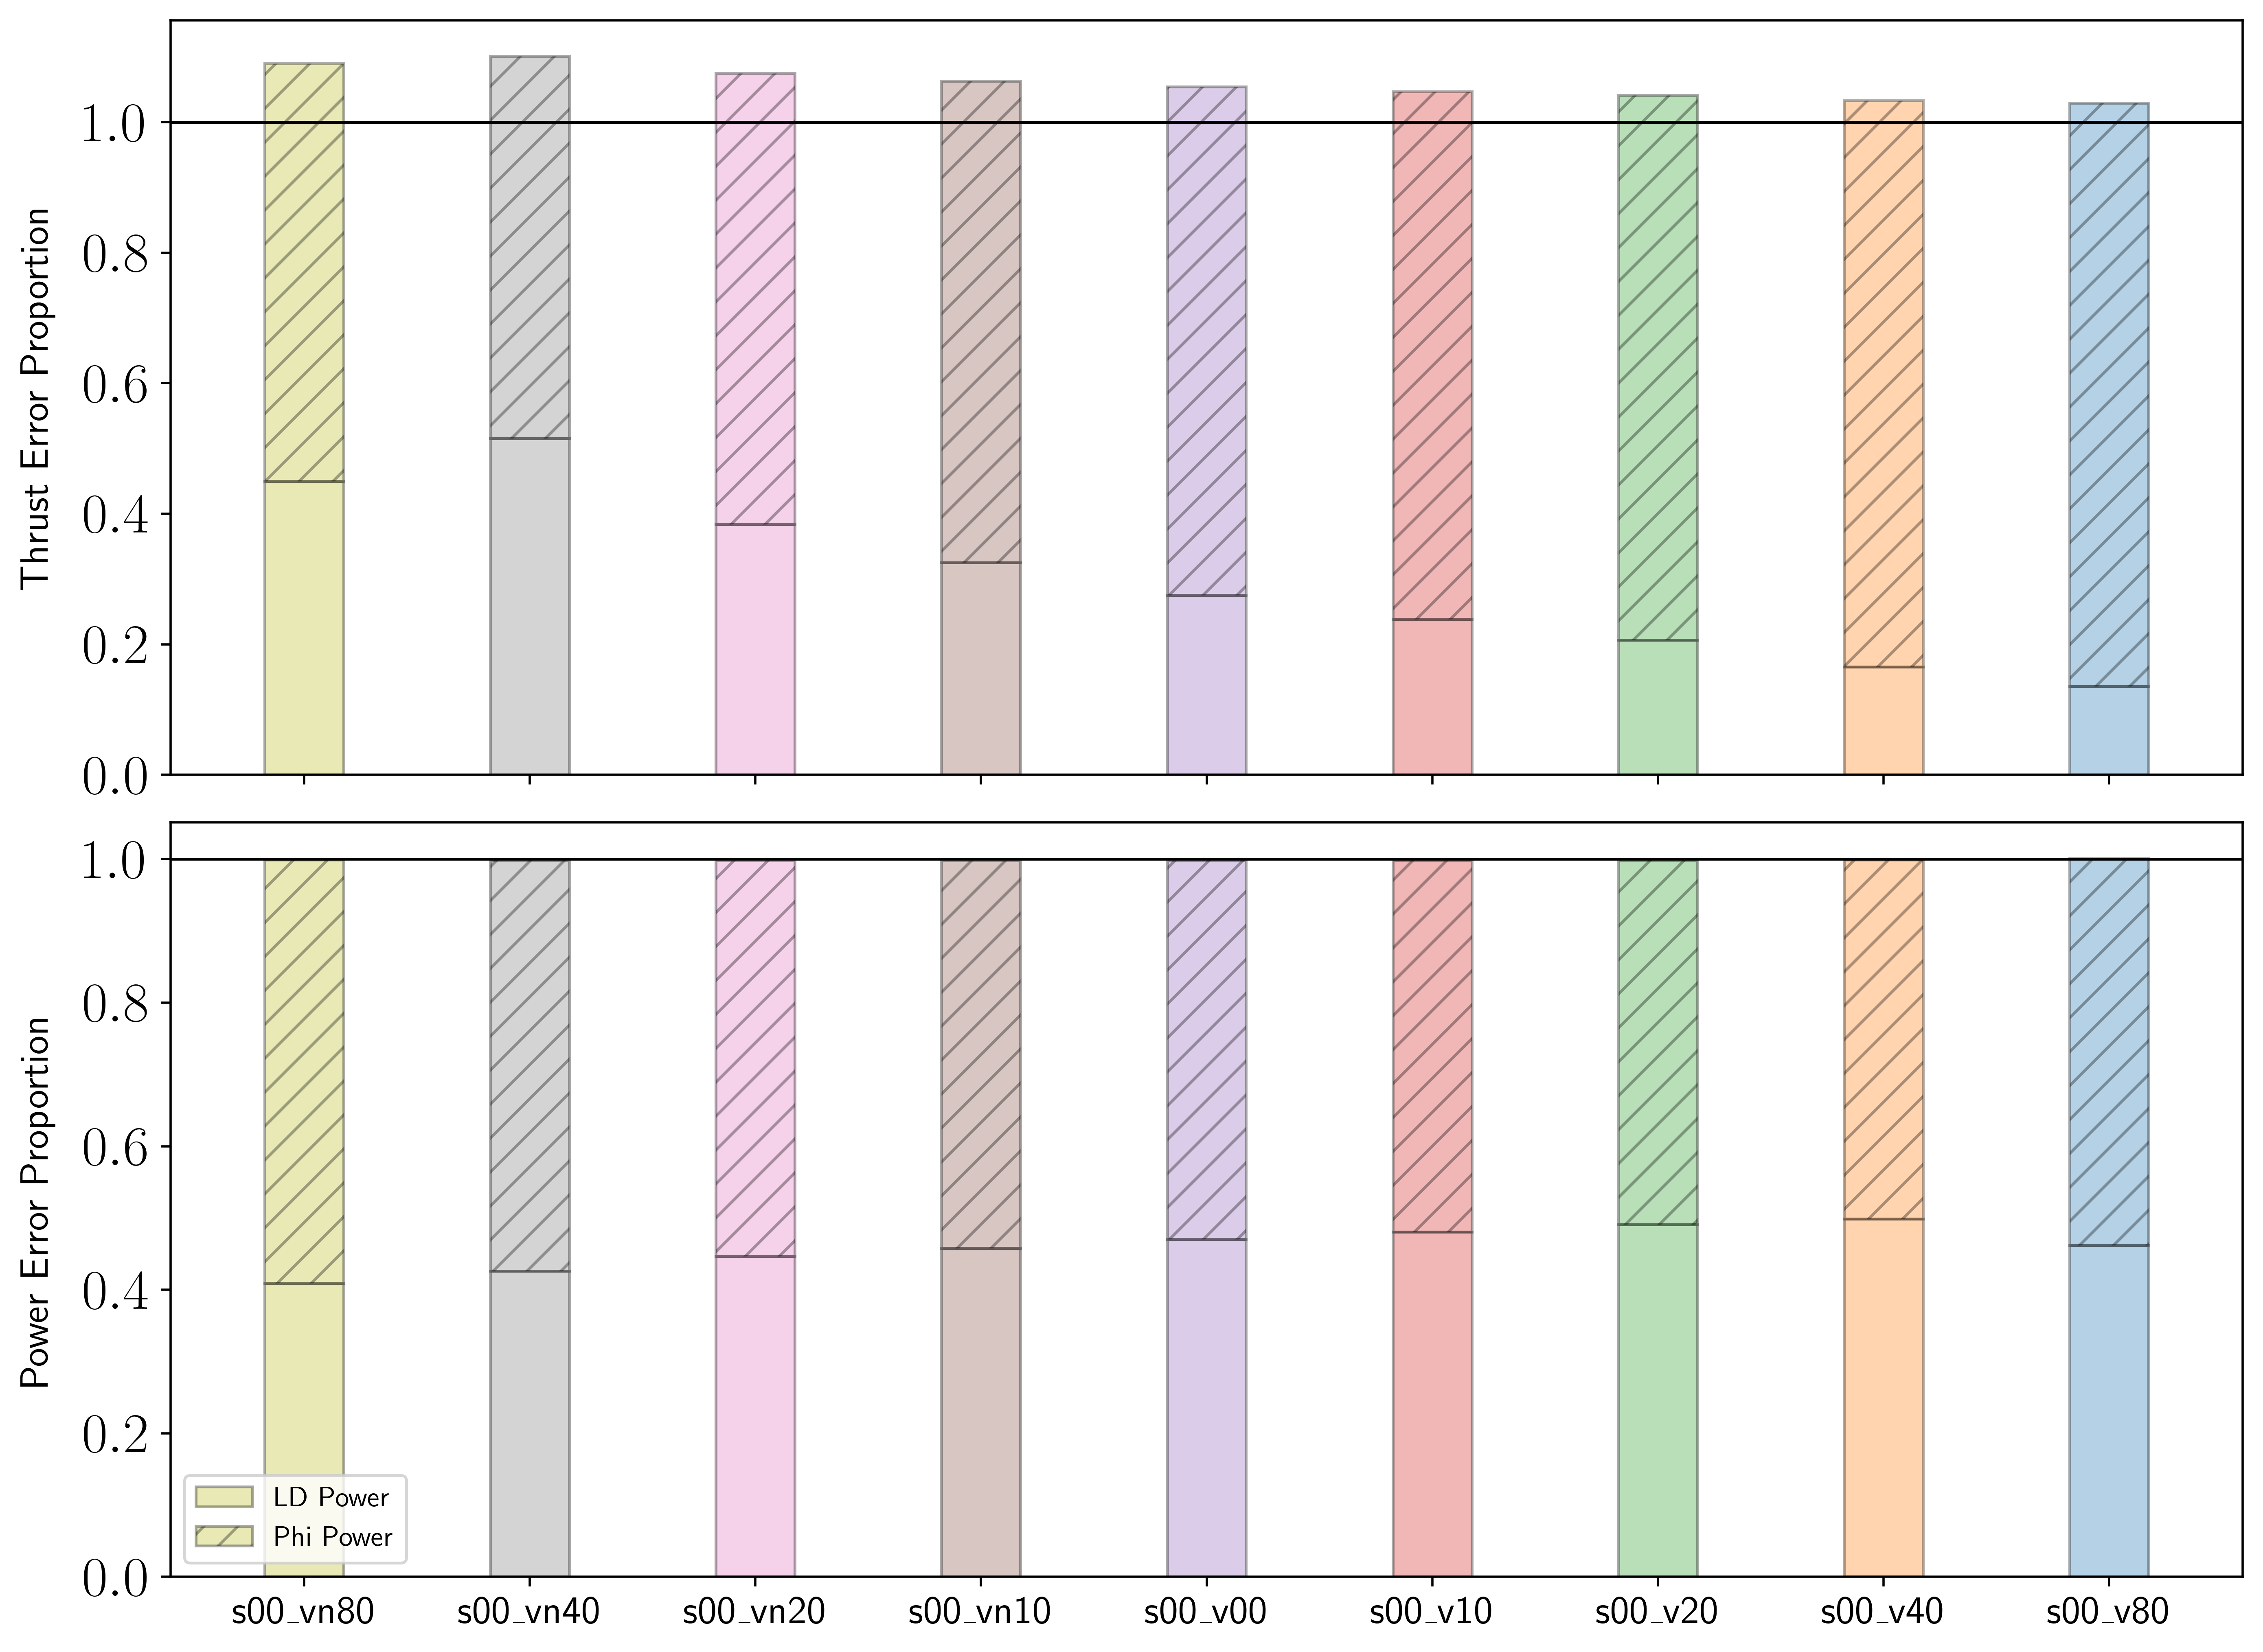

In [114]:
# Dimensional
colors = sns.color_palette("tab10", 9)

width = 0.35
alpha = 1/3
fontsize = 14
labfontsize = 10

full_colors = colors[::-1]

ind = np.arange(len(new_names))

fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(11, 8), sharex=True, constrained_layout=True)

for a in ax:
    a.axhline(1, color='black', linestyle='solid', linewidth=1)

LD_t_prop = lift_t_err / total_t_err
phi_t_prop = phi_t_err / total_t_err

LD_p_prop = lift_p_err / total_p_err
phi_p_prop = phi_p_err / total_p_err

# Plotting
for count in range(len(new_names)):
    # --- Thrust
    ax[0].bar(ind[count], LD_t_prop[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha, label='LD Thrust' if count == 0 else "")
    
    ax[0].bar(ind[count], phi_t_prop[count], width,
              bottom=LD_t_prop[count],
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//', label='Phi Thrust' if count == 0 else "")
    
    ax[0].set_ylabel(r'Thrust Error Proportion', fontsize=fontsize, labelpad=10)

    # --- Power
    ax[1].bar(ind[count], LD_p_prop[count], width,
              color=full_colors[count], edgecolor='black', alpha=alpha, label='LD Power' if count == 0 else "")
    
    ax[1].bar(ind[count], phi_p_prop[count], width,
              bottom=LD_p_prop[count],
              color=full_colors[count], edgecolor='black', alpha=alpha, hatch='//', label='Phi Power' if count == 0 else "")

    ax[1].set_ylabel(r'Power Error Proportion', fontsize=fontsize, labelpad=10)

# Optional: Add legend and xticks
ax[1].set_xticks(ind)
ax[1].set_xticklabels(new_names, fontsize=fontsize)
ax[1].legend(fontsize=labfontsize)

plt.show()
